#### Solution overview

### Imputation Evaluation 

#### RMSE and NRMSE avg + missing data rate + sample size (table and txt)

In [ ]:
# ==========================
# Config
# ==========================
ORIGINAL_FOLDER = "../longest_interval_datasets"  # folder with originals
IMPUTED_FOLDER  = "../imputation_results_final_longest/imputed_datasets_all"            # folder with imputed CSVs
VALUE_COL       = "Vazao"                      # column to compare
ORIGINAL_SUFFIX = "_longest.csv"               # how original files end
OUTPUT_CSV      = "rmse_nrmse_summary.csv"     # where to save the summary
NORMALIZATION   = "range"                      # "range" or "std" for NRMSE
OUTPUT_CSV_BY_RATE = "rmse_nrmse_by_method_missingrate.csv"
# ==========================

import os, re
import numpy as np
import pandas as pd

def _rmse(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = ~(np.isnan(a) | np.isnan(b))
    if not np.any(mask):
        return np.nan
    return float(np.sqrt(np.mean((a[mask] - b[mask])**2)))

def _nrmse(a, b, mode="range"):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = ~(np.isnan(a) | np.isnan(b))
    if not np.any(mask):
        return np.nan
    rmse = np.sqrt(np.mean((a[mask] - b[mask])**2))
    denom = None
    if mode == "range":
        rng = np.nanmax(a[mask]) - np.nanmin(a[mask])
        denom = rng if rng and rng > 0 else np.nan
    elif mode == "std":
        sd = np.nanstd(a[mask], ddof=0)
        denom = sd if sd and sd > 0 else np.nan
    else:
        raise ValueError("NORMALIZATION must be 'range' or 'std'")
    if np.isnan(denom):
        # fallback: use std if range is zero (or vice-versa)
        alt = np.nanstd(a[mask], ddof=0) if mode == "range" else (np.nanmax(a[mask]) - np.nanmin(a[mask]))
        denom = alt if alt and alt > 0 else np.nan
    return float(rmse / denom) if not np.isnan(denom) else np.nan

def _infer_base_and_method(fname):
    """
    Extrai (base, method) de nomes como:
      base_mr20_Method(_imputed).csv
      base_Method(_imputed).csv
      base_..._mr10_Method_imputed.csv
    Retorna strings (base, method).
    """
    name = os.path.splitext(os.path.basename(fname))[0]
    # remove sufixos comuns no fim
    name = re.sub(r'_imputed$', '', name, flags=re.IGNORECASE)

    # 1) base_mrXX_method
    m = re.match(r'^(?P<base>.+?)_mr(?P<mr>\d{1,3})_(?P<method>.+)$', name, flags=re.IGNORECASE)
    if m:
        base = m.group('base')
        method = m.group('method')
        return base, method

    # 2) base_method  (sem mr)
    m = re.match(r'^(?P<base>.+?)_(?P<method>[^_]+)$', name)
    if m:
        return m.group('base'), m.group('method')

    return name


def _read_value_series(path, col):
    df = pd.read_csv(path)
    if col not in df.columns:
        # try case-insensitive match
        match = [c for c in df.columns if c.strip().lower() == col.strip().lower()]
        if match:
            col = match[0]
        else:
            raise ValueError(f"Column '{col}' not found in {path}. Available: {list(df.columns)}")
    return df[col].to_numpy()

imputed_files = [f for f in os.listdir(IMPUTED_FOLDER) if f.lower().endswith(".csv")]
results = []

for imp_file in sorted(imputed_files):
    imp_path = os.path.join(IMPUTED_FOLDER, imp_file)
    base, method = _infer_base_and_method(imp_file)

    #  extrair missing_rate do nome do arquivo imputado (ex.: _mr10_)
    mr_match = re.search(r"_mr(\d{1,3})\b", imp_file, flags=re.IGNORECASE)
    missing_rate = int(mr_match.group(1)) if mr_match else np.nan

    # Try the straightforward original name: base + ORIGINAL_SUFFIX
    orig_file = f"{base}{ORIGINAL_SUFFIX}"
    orig_path = os.path.join(ORIGINAL_FOLDER, orig_file)

    if not os.path.exists(orig_path):
        # Try a looser match: find any file in ORIGINAL_FOLDER that starts with base and endswith ORIGINAL_SUFFIX
        candidates = [f for f in os.listdir(ORIGINAL_FOLDER)
                      if f.endswith(ORIGINAL_SUFFIX) and f.startswith(base)]
        if candidates:
            orig_path = os.path.join(ORIGINAL_FOLDER, candidates[0])
        else:
            # last fallback: search for {base}_longest*.csv
            candidates = [f for f in os.listdir(ORIGINAL_FOLDER)
                          if f.startswith(base) and f.lower().endswith(".csv") and "_longest" in f]
            if candidates:
                orig_path = os.path.join(ORIGINAL_FOLDER, candidates[0])
            else:
                print(f"[skip] No original found for imputed '{imp_file}' (base='{base}').")
                continue

    try:
        y_imp = _read_value_series(imp_path, VALUE_COL)
        y_ori = _read_value_series(orig_path, VALUE_COL)
    except Exception as e:
        print(f"[skip] Read error for '{imp_file}': {e}")
        continue

    # Align by index length (row-wise comparison)
    n = min(len(y_imp), len(y_ori))
    y_imp = y_imp[:n]
    y_ori = y_ori[:n]

    r = _rmse(y_ori, y_imp)
    nr = _nrmse(y_ori, y_imp, mode=NORMALIZATION)

    results.append({
        "dataset_base": os.path.splitext(os.path.basename(orig_path))[0].replace(ORIGINAL_SUFFIX.replace(".csv",""), ""),
        "imputed_file": imp_file,
        "original_file": os.path.basename(orig_path),
        "method": method,
        "n": int(n),
        "rmse": r,
        "nrmse": nr,
        "nrmse_mode": NORMALIZATION,
        "missing_rate": missing_rate
    })

summary_df = pd.DataFrame(results).sort_values(["dataset_base","method"]).reset_index(drop=True)
display(summary_df)

# Save to CSV for later analysis
summary_df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved: {OUTPUT_CSV}  | rows={len(summary_df)}")

# # ==========================
# # Agregado por método e missing_rate
# # ==========================
# # Recomendado: garantir tipos consistentes
# summary_df["missing_rate"] = pd.to_numeric(summary_df["missing_rate"], errors="coerce")

# # Agrega por (method, missing_rate, nrmse_mode)
# agg_df = (
#     summary_df
#     .groupby(["method", "missing_rate", "nrmse_mode"], dropna=False)
#     .agg(
#         rmse_avg=("rmse", "mean"),
#         nrmse_avg=("nrmse", "mean"),
#         # Se houver múltiplos arquivos no grupo, marque como "<multiple>"
#         imputed_file=("imputed_file", lambda s: s.iloc[0] if s.nunique() == 1 else "<multiple>"),
#         original_file=("original_file", lambda s: s.iloc[0] if s.nunique() == 1 else "<multiple>")
#     )
#     .reset_index()
# )

# # Reordena colunas conforme solicitado
# agg_df = agg_df[["imputed_file", "original_file", "method", "missing_rate", "rmse_avg", "nrmse_avg", "nrmse_mode"]]

# # Salva CSV agregado
# agg_df.to_csv(OUTPUT_CSV_BY_RATE, index=False)
# print(f"Saved: {OUTPUT_CSV_BY_RATE}  | rows={len(agg_df)}")


NameError: name 'INVALID_LINK_SUBSTRINGS' is not defined

In [11]:
import pandas as pd
import re

# === 1. Carregar o dataset ===
summary_df = pd.read_csv(OUTPUT_CSV)
valid_links = [
    "esmond data ankara.ulakbim.gov.tr to psmp-gn-bw-lis-pt.geant.org 10-24-2023",
    "esmond data sonda.rediris.es to psmp-gn-bw-lis-pt.geant.org 10-24-2023",
    "esmond data ankara.ulakbim.gov.tr 10-24-2023",
    "esmond data psmp-gn-bw-poz-pl.geant.org to pspmp-anella.csuc.cat 10-24-2023",
    "esmond data pspmp-anella.csuc.cat to psmp-gn-bw-poz-pl.geant.org 10-24-2023",
    "esmond data psmp-gn-bw-vie-at.geant.org to psmall.lut.ac.uk 10-24-2023",
    "esmond data psmall.lut.ac.uk to psmp-gn-bw-vie-at.geant.org 10-24-2023",
    "esmond data psmp-gn-bw-lis-pt.geant.org to perfsonar.restena.lu 10-24-2023",
    "esmond data ankara.ulakbim.gov.tr to psmp-gn-bw-poz-pl.geant.org 10-24-2023",
]

# summary_df = summary_df[summary_df["dataset_base"].isin(valid_links)].copy()

invalid_links = ["esmond data perfsonar.restena.lu to psmp-gn-bw-lis-pt.geant.org 10-24-2023"]

summary_df = summary_df[~summary_df["dataset_base"].isin(invalid_links)].copy()



# === 2. Extrair missing_rate do nome do arquivo ===
def extract_missing_rate(filename: str) -> float:
    """
    Extrai o missing rate do nome do arquivo (ex: '_mr10_') e converte para proporção.
    """
    match = re.search(r'_mr(\d+)_', str(filename))
    if match:
        return int(match.group(1)) / 100.0  # ex: 10 → 0.10
    return None

summary_df["missing_rate"] = summary_df["imputed_file"].apply(extract_missing_rate)

# === 3. Converter RMSE para megabits ===
summary_df["rmse"] = summary_df["rmse"] / 1e6  # bits → Mbit

# === 4. Agrupar por método e missing rate ===
summary_avg = (
    summary_df
    .groupby(["method", "missing_rate"], as_index=False)
    .agg({
        "rmse": ["mean", "std"],           # média e desvio padrão do RMSE (agora em Mbit)
        "nrmse": ["mean", "std"],          # média e desvio padrão do NRMSE
        "nrmse_mode": "first",             # modo de normalização (range/std)
        "dataset_base": "count"            # número de arquivos usados
    })
    .rename(columns={"dataset_base": "number_of_files"})
    .sort_values(["method", "missing_rate"])
)

# Ajustar nomes das colunas após a agregação
summary_avg.columns = ['_'.join(col).strip('_') for col in summary_avg.columns.values]

# Renomear colunas para melhor clareza
summary_avg = summary_avg.rename(columns={
    'rmse_mean': 'rmse_mean',
    'rmse_std': 'rmse_std',
    'nrmse_mean': 'nrmse_mean', 
    'nrmse_std': 'nrmse_std',
    'nrmse_mode_first': 'nrmse_mode',
    'number_of_files': 'number_of_files'
})

# Arredondar valores
summary_avg["rmse_mean"] = summary_avg["rmse_mean"].round(4)
summary_avg["rmse_std"] = summary_avg["rmse_std"].round(4)
summary_avg["nrmse_mean"] = summary_avg["nrmse_mean"].round(4)
summary_avg["nrmse_std"] = summary_avg["nrmse_std"].round(4)

# === 5. Exibir resultado ===
print(summary_avg)
# (Opcional) summary_avg.to_csv("summary_avg_by_method_missingrate.csv", index=False)


# === 6. Exibir resultado final ===
print(summary_avg)

# (Opcional) salvar resultado
# summary_avg.to_csv("summary_avg_by_method_missingrate.csv", index=False)

            method  missing_rate  rmse_mean  rmse_std  nrmse_mean  nrmse_std  \
0            ARIMA           0.1    23.9710    9.6591      0.0316     0.0126   
1            ARIMA           0.2    40.0399   18.7402      0.0504     0.0165   
2            ARIMA           0.3    48.4863   21.6290      0.0622     0.0219   
3            ARIMA           0.4    61.1876   22.7162      0.0788     0.0233   
4      HoltWinters           0.1    23.1250   10.3516      0.0309     0.0143   
5      HoltWinters           0.2    38.4829   16.3341      0.0493     0.0179   
6      HoltWinters           0.3    46.3847   19.1360      0.0607     0.0248   
7      HoltWinters           0.4    58.5535   21.5150      0.0780     0.0319   
8      KNN_Sklearn           0.1    27.2927   22.0024      0.0328     0.0149   
9      KNN_Sklearn           0.2    43.3894   33.1029      0.0509     0.0189   
10     KNN_Sklearn           0.3    50.7036   37.0871      0.0606     0.0233   
11     KNN_Sklearn           0.4    60.1

In [2]:
# ==========================
# Config
# ==========================
ORIGINAL_FOLDER = "../longest_interval_datasets"   # pasta dos originais (longest)
IMPUTED_FOLDER  = "../imputation_results_final_longest/imputed_datasets_all"            # folder with imputed CSVs
VALUE_COL       = "Vazao"                          # coluna do valor
ORIGINAL_SUFFIX = "_longest.csv"                   # sufixo do original
OUTPUT_SIMILARITY_CSV = "similarity_summary.csv"
OUTPUT_SIMIL_BY_RATE  = "similarity_by_method_missingrate.csv"

# FFT / Periodicidade
MIN_PERIOD = 4           # em amostras
MAX_PERIOD = None        # se None: usa len(y)//4 no cálculo
SMOOTH_TREND_FLOOR = 5   # janela mínima para média móvel da tendência

# ==========================

import os, re, warnings
import numpy as np
import pandas as pd

from scipy.spatial.distance import euclidean
from numpy.fft import rfft, rfftfreq
try:
    from fastdtw import fastdtw
    _HAS_FDTW = True
except Exception:
    warnings.warn("fastdtw não encontrado; caindo para DTW simples (O(n^2)).")
    _HAS_FDTW = False

# ---------- Helpers ----------

def _to_1d(x):
    """Garante vetor 1-D (evita erros em rfft/np.correlate/fastdtw)."""
    if x is None:
        return np.array([])
    x_array = np.asarray(x, dtype=float)
    # Remove dimensões extras e garante que é 1-D
    x_flat = np.ravel(x_array)
    return x_flat

def _infer_base_and_method(fname):
    """
    Extrai (base, method) de nomes como:
      base_mr20_Method(_imputed).csv
      base_Method(_imputed).csv
      base_..._mr10_Method_imputed.csv
    Retorna strings (base, method).
    """
    name = os.path.splitext(os.path.basename(fname))[0]
    # remove sufixos comuns no fim
    name = re.sub(r'_imputed$', '', name, flags=re.IGNORECASE)

    # 1) base_mrXX_method
    m = re.match(r'^(?P<base>.+?)_mr(?P<mr>\d{1,3})_(?P<method>.+)$', name, flags=re.IGNORECASE)
    if m:
        base = m.group('base')
        method = m.group('method')
        return base, method

    # 2) base_method  (sem mr)
    m = re.match(r'^(?P<base>.+?)_(?P<method>[^_]+)$', name)
    if m:
        return m.group('base'), m.group('method')



    return name

# def _infer_base_and_method(fname):
#     """
#     Extrai (base, method) de padrões comuns:
#       base_mr20_Method.csv
#       base_Method.csv
#       base_..._Imputed.csv
#     """
#     name = os.path.splitext(fname)[0]
#     method = name.split("_")[-1]
#     base_guess = name[:-(len(method)+1)] if "_" in name else name
#     base_guess = re.sub(r"_mr\d{1,3}$", "", base_guess)
#     base_guess = re.sub(r"_mr\d{1,3}_.*$", "", base_guess)
#     return base_guess, method

def _read_value_series(path, col):
    df = pd.read_csv(path)
    if col not in df.columns:
        match = [c for c in df.columns if c.strip().lower() == col.strip().lower()]
        if match:
            col = match[0]
        else:
            raise ValueError(f"Coluna '{col}' não encontrada em {path}. Disponíveis: {list(df.columns)}")
    y = df[col].to_numpy(dtype=float)
    return _to_1d(y)

# ---------- Métricas básicas ----------

def _safe_align(a, b):
    a = _to_1d(a); b = _to_1d(b)
    n = int(min(len(a), len(b)))
    return a[:n], b[:n], n

def _zscore(x):
    x = _to_1d(x)
    mu = np.nanmean(x); sd = np.nanstd(x)
    if not np.isfinite(sd) or sd == 0:
        return np.zeros_like(x)
    return (x - mu)/sd

# ---------- DTW ----------

def _dtw_distance(a, b, use_zscore=True):
    """
    Distância DTW robusta a NaNs/INFs. 
    - Interpola lacunas, opcionalmente padroniza (z-score), e tenta fastdtw.
    - Se falhar, usa DTW O(n^2).
    """
    a, b, n = _prepare_for_distance(a, b, zscore=use_zscore)
    if n == 0:
        return np.nan

    if _HAS_FDTW:
        try:
            d, _ = fastdtw(a, b, dist=euclidean)
            return float(d)
        except Exception as e:
            warnings.warn(f"fastdtw falhou: {e}. Usando DTW O(n^2).")

    # Fallback DTW O(n^2) com custo |ai - bj|
    n, m = len(a), len(b)
    if n == 0 or m == 0:
        return np.nan
    D = np.full((n+1, m+1), np.inf, dtype=float)
    D[0, 0] = 0.0
    for i in range(1, n+1):
        ai = a[i-1]
        for j in range(1, m+1):
            # ai e b[j-1] já são finitos
            cost = abs(ai - b[j-1])
            D[i, j] = cost + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    return float(D[n, m])


def _dtw_similarity(d, scale="inv1_plus_d"):
    """Converte distância DTW em [0,1] (maior = mais similar)."""
    if d is None or not np.isfinite(d): 
        return np.nan
    if scale == "inv1_plus_d":
        return 1.0 / (1.0 + float(d))
    return np.nan

# ---------- Periodicidade por FFT ----------

def _dominant_period_fft(y, min_period=MIN_PERIOD, max_period=None):
    y = _to_1d(y)
    if len(y) == 0:
        return np.nan, None, None
        
    y = y - np.nanmean(y)
    n = len(y)
    if n < (min_period*2):
        return np.nan, None, None  # série muito curta
    if max_period is None:
        max_period = max(min_period+1, min(n//4, 365))  # limite razoável
    # FFT
    y_filled = np.where(np.isnan(y), np.nanmean(y), y)
    try:
        amp = np.abs(rfft(y_filled))
        freqs = rfftfreq(n, d=1.0)  # amostragem unitária
    except Exception as e:
        warnings.warn(f"FFT failed: {e}")
        return np.nan, None, None
        
    # converte faixa de período para frequências
    fmax = 1.0 / max_period
    fmin = 1.0 / min_period
    m = (freqs >= fmax) & (freqs <= fmin)
    if not np.any(m):
        return np.nan, amp, freqs
    k = np.argmax(amp[m])
    freq_dom = freqs[m][k]
    if freq_dom <= 0:
        return np.nan, amp, freqs
    period_dom = int(round(1.0 / freq_dom))
    return period_dom, amp, freqs

def _cosine_similarity(u, v):
    u = _to_1d(u); v = _to_1d(v)
    if len(u) == 0 or len(v) == 0:
        return np.nan
        
    u_norm = np.linalg.norm(u)
    v_norm = np.linalg.norm(v)
    
    if u_norm < 1e-12 or v_norm < 1e-12:
        return np.nan
        
    u = u / u_norm
    v = v / v_norm
    
    # Garante que os vetores têm o mesmo comprimento
    min_len = min(len(u), len(v))
    u = u[:min_len]
    v = v[:min_len]
    
    return float(np.clip(np.dot(u, v), -1.0, 1.0))

def _periodicity_similarity(y1, y2):
    p1, spec1, f1 = _dominant_period_fft(y1, MIN_PERIOD, MAX_PERIOD)
    p2, spec2, f2 = _dominant_period_fft(y2, MIN_PERIOD, MAX_PERIOD)
    
    # similaridade de período dominante
    if np.isnan(p1) or np.isnan(p2):
        period_sim = np.nan
        period_diff_ratio = np.nan
    else:
        denom = max(p1, p2)
        period_diff_ratio = abs(p1 - p2)/denom if denom>0 else np.nan
        period_sim = 1.0 - period_diff_ratio  # 1 - |Δ|/max
    
    # similaridade espectral (alinhar comprimentos)
    if spec1 is None or spec2 is None:
        spec_cos_sim = np.nan
    else:
        spec_cos_sim = _cosine_similarity(spec1, spec2)
        
    return {
        "period_dom_ori": p1,
        "period_dom_imp": p2,
        "period_diff_ratio": period_diff_ratio,
        "period_similarity": period_sim,
        "spectral_cosine_similarity": spec_cos_sim
    }

# ---------- Tendência ----------

def _moving_avg(x, window):
    x = _to_1d(x)
    if len(x) == 0:
        return np.array([])
        
    if window < 1: 
        return x.copy()
    
    # preenche NaN com média para evitar artefatos
    x_mean = np.nanmean(x)
    if not np.isfinite(x_mean):
        x_mean = 0.0
    xf = np.where(np.isnan(x), x_mean, x)
    
    # média móvel centrada com bordas replicadas
    k = int(max(1, window))
    pad = k//2
    xp = np.pad(xf, (pad, pad), mode='edge')
    c = np.convolve(xp, np.ones(k)/k, mode='valid')
    return _to_1d(c)

def _trend_similarity(y1, y2):
    y1 = _to_1d(y1); y2 = _to_1d(y2)
    if len(y1) == 0 or len(y2) == 0:
        return {
            "trend_window": np.nan,
            "trend_corr": np.nan
        }
        
    p1, _, _ = _dominant_period_fft(y1, MIN_PERIOD, MAX_PERIOD)
    p2, _, _ = _dominant_period_fft(y2, MIN_PERIOD, MAX_PERIOD)
    
    # usa uma janela média dos dois períodos; cai para piso se faltarem períodos
    if np.isnan(p1) and np.isnan(p2):
        win = SMOOTH_TREND_FLOOR
    else:
        vals = [v for v in [p1, p2] if np.isfinite(v)]
        win = int(np.clip(np.nanmean(vals) if vals else SMOOTH_TREND_FLOOR, SMOOTH_TREND_FLOOR, 9999))
    
    t1 = _moving_avg(y1, win)
    t2 = _moving_avg(y2, win)
    t1, t2, n = _safe_align(t1, t2)
    
    if n == 0:
        return {
            "trend_window": win,
            "trend_corr": np.nan
        }
    
    # correlação de Pearson (pós z-score)
    z1 = _zscore(t1); z2 = _zscore(t2)
    m = ~(np.isnan(z1) | np.isnan(z2))
    
    if np.sum(m) < 2:
        trend_corr = np.nan
    else:
        try:
            trend_corr = float(np.corrcoef(z1[m], z2[m])[0,1])
        except Exception:
            trend_corr = np.nan
            
    return {
        "trend_window": win,
        "trend_corr": trend_corr
    }

def _interpolate_nans_1d(x: np.ndarray) -> np.ndarray:
    """Interpola NaNs em 1-D (linear no índice). Se não houver pontos suficientes, preenche com média."""
    x = _to_1d(x).astype(float, copy=False)
    if x.size == 0:
        return x
    if not (np.isnan(x).any() or np.isinf(x).any()):
        return x
    # Troca infs por NaN para tratar junto
    x = np.where(np.isfinite(x), x, np.nan)

    idx = np.arange(x.size)
    mask = ~np.isnan(x)
    if mask.sum() >= 2:
        x_interp = x.copy()
        x_interp[~mask] = np.interp(idx[~mask], idx[mask], x[mask])
    else:
        fill = np.nanmean(x)
        if not np.isfinite(fill):
            fill = 0.0
        x_interp = np.where(np.isnan(x), fill, x)
    return x_interp

def _prepare_for_distance(a, b, zscore=True):
    """Alinha, interpola NaNs/INFs e (opcional) aplica z-score antes da distância."""
    a = _to_1d(a); b = _to_1d(b)
    a, b, n = _safe_align(a, b)
    if n == 0:
        return a, b, n
    a = _interpolate_nans_1d(a)
    b = _interpolate_nans_1d(b)
    if zscore:
        a = _zscore(a)
        b = _zscore(b)
        # após zscore, ainda pode sobrar NaN se sd=0: substitui por 0
        a = np.where(np.isfinite(a), a, 0.0)
        b = np.where(np.isfinite(b), b, 0.0)
    else:
        # garante finitos
        a = np.where(np.isfinite(a), a, 0.0)
        b = np.where(np.isfinite(b), b, 0.0)
    return a, b, n


# ---------- Autocorrelação ----------

def _acf(x, nlags):
    x = _to_1d(x)
    if len(x) == 0:
        return np.array([np.nan]*(nlags+1))
        
    x = x - np.nanmean(x)
    # preenche NaN com média
    x_mean = np.nanmean(x)
    if not np.isfinite(x_mean):
        x_mean = 0.0
    x = np.where(np.isnan(x), x_mean, x)
    
    n = len(x)
    if n < 2: 
        return np.array([np.nan]*(nlags+1))
        
    try:
        ac = np.correlate(x, x, mode='full')[n-1:n+nlags]
        ac = ac / (ac[0] + 1e-12)
        return _to_1d(ac)
    except Exception:
        return np.array([np.nan]*(nlags+1))

# ==========================
# Loop principal
# ==========================

imputed_files = [f for f in os.listdir(IMPUTED_FOLDER) if f.lower().endswith(".csv")]
rows = []

for imp_file in sorted(imputed_files):
    imp_path = os.path.join(IMPUTED_FOLDER, imp_file)
    base, method = _infer_base_and_method(imp_file)

    # missing_rate (ex.: _mr10_)
    mr_match = re.search(r"_mr(\d{1,3})\b", imp_file, flags=re.IGNORECASE)
    missing_rate = int(mr_match.group(1)) if mr_match else np.nan

    # original esperado
    orig_file = f"{base}{ORIGINAL_SUFFIX}"
    orig_path = os.path.join(ORIGINAL_FOLDER, orig_file)

    if not os.path.exists(orig_path):
        candidates = [f for f in os.listdir(ORIGINAL_FOLDER)
                      if f.endswith(ORIGINAL_SUFFIX) and f.startswith(base)]
        if candidates:
            orig_path = os.path.join(ORIGINAL_FOLDER, candidates[0])
        else:
            candidates = [f for f in os.listdir(ORIGINAL_FOLDER)
                          if f.startswith(base) and f.lower().endswith(".csv") and "_longest" in f]
            if candidates:
                orig_path = os.path.join(ORIGINAL_FOLDER, candidates[0])
            else:
                print(f"[skip] Original não encontrado p/ '{imp_file}' (base='{base}').")
                continue

    try:
        y_imp = _read_value_series(imp_path, VALUE_COL)
        y_ori = _read_value_series(orig_path, VALUE_COL)
    except Exception as e:
        print(f"[skip] Erro de leitura '{imp_file}': {e}")
        continue

    y_ori, y_imp, n = _safe_align(y_ori, y_imp)
    if n < 8:
        print(f"[skip] Série curta ({n}) para '{imp_file}'.")
        continue

    print(f"Processando: {imp_file} (n={n})")

    # DTW
    try:
        dtw_d = _dtw_distance(y_ori, y_imp)
        dtw_sim = _dtw_similarity(dtw_d)
    except Exception as e:
        print(f"  Erro DTW: {e}")
        dtw_d = np.nan
        dtw_sim = np.nan

    # Periodicidade
    try:
        per_metrics = _periodicity_similarity(y_ori, y_imp)
    except Exception as e:
        print(f"  Erro periodicidade: {e}")
        per_metrics = {
            "period_dom_ori": np.nan,
            "period_dom_imp": np.nan,
            "period_diff_ratio": np.nan,
            "period_similarity": np.nan,
            "spectral_cosine_similarity": np.nan
        }

    # Tendência
    try:
        tr_metrics = _trend_similarity(y_ori, y_imp)
    except Exception as e:
        print(f"  Erro tendência: {e}")
        tr_metrics = {
            "trend_window": np.nan,
            "trend_corr": np.nan
        }

    rows.append({
        "dataset_base": os.path.splitext(os.path.basename(orig_path))[0].replace(ORIGINAL_SUFFIX.replace(".csv",""), ""),
        "imputed_file": imp_file,
        "original_file": os.path.basename(orig_path),
        "method": method,
        "missing_rate": missing_rate,
        "n": int(n),

        # DTW
        "dtw_distance": dtw_d,
        "dtw_similarity": dtw_sim,

        # Periodicidade
        "period_dom_ori": per_metrics["period_dom_ori"],
        "period_dom_imp": per_metrics["period_dom_imp"],
        "period_diff_ratio": per_metrics["period_diff_ratio"],
        "period_similarity": per_metrics["period_similarity"],
        "spectral_cosine_similarity": per_metrics["spectral_cosine_similarity"],

        # Tendência
        "trend_window": tr_metrics["trend_window"],
        "trend_corr": tr_metrics["trend_corr"],
    })

if rows:
    similarity_df = pd.DataFrame(rows).sort_values(["dataset_base","method","missing_rate"]).reset_index(drop=True)
    try:
        display(similarity_df)
    except Exception:
        pass

    similarity_df.to_csv(OUTPUT_SIMILARITY_CSV, index=False)
    print(f"Saved: {OUTPUT_SIMILARITY_CSV}  | rows={len(similarity_df)}")

    # ==========================
    # Agregado por método e missing_rate (médias)
    # ==========================
    similarity_df["missing_rate"] = pd.to_numeric(similarity_df["missing_rate"], errors="coerce")

    agg = (
        similarity_df
        .groupby(["method","missing_rate"], dropna=False)
        .agg(
            n_series=("imputed_file","count"),
            dtw_distance_avg=("dtw_distance","mean"),
            dtw_similarity_avg=("dtw_similarity","mean"),
            period_diff_ratio_avg=("period_diff_ratio","mean"),
            period_similarity_avg=("period_similarity","mean"),
            spectral_cosine_similarity_avg=("spectral_cosine_similarity","mean"),
            trend_corr_avg=("trend_corr","mean"),
        )
        .reset_index()
    )

    try:
        display(agg)
    except Exception:
        pass

    agg.to_csv(OUTPUT_SIMIL_BY_RATE, index=False)
    print(f"Saved: {OUTPUT_SIMIL_BY_RATE}  | rows={len(agg)}")
else:
    print("Nenhum dado processado. Verifique os caminhos e arquivos.")

Processando: esmond data perfsonar-ankara.ulakbim.gov.tr to psmp-gn-bw-lis-pt.geant.org 10-24-2023_mr10_ARIMA_imputed.csv (n=1015)


C:\Users\Clara\AppData\Local\Temp\ipykernel_2352\1912190091.py:126: UserWarning: fastdtw falhou: Input vector should be 1-D.. Usando DTW O(n^2).
  warnings.warn(f"fastdtw falhou: {e}. Usando DTW O(n^2).")


Processando: esmond data perfsonar-ankara.ulakbim.gov.tr to psmp-gn-bw-lis-pt.geant.org 10-24-2023_mr10_HoltWinters_imputed.csv (n=1015)


C:\Users\Clara\AppData\Local\Temp\ipykernel_2352\1912190091.py:126: UserWarning: fastdtw falhou: Input vector should be 1-D.. Usando DTW O(n^2).
  warnings.warn(f"fastdtw falhou: {e}. Usando DTW O(n^2).")


Processando: esmond data perfsonar-ankara.ulakbim.gov.tr to psmp-gn-bw-lis-pt.geant.org 10-24-2023_mr10_KNN_Sklearn_imputed.csv (n=1015)


...

C:\Users\Clara\AppData\Local\Temp\ipykernel_2352\1912190091.py:126: UserWarning: fastdtw falhou: Input vector should be 1-D.. Usando DTW O(n^2).
  warnings.warn(f"fastdtw falhou: {e}. Usando DTW O(n^2).")


,dataset_base,imputed_file,original_file,method,missing_rate,n,dtw_distance,dtw_similarity,period_dom_ori,period_dom_imp,period_diff_ratio,period_similarity,spectral_cosine_similarity,trend_window,trend_corr
0,esmond data perfsonar-ankara.ulakbim.gov.tr to...,esmond data perfsonar-ankara.ulakbim.gov.tr to...,esmond data perfsonar-ankara.ulakbim.gov.tr to...,ARIMA,NaN,1015,114.117784,0.008687,6,5,0.166667,0.833333,0.969491,5,0.954476
1,esmond data perfsonar-ankara.ulakbim.gov.tr to...,esmond data perfsonar-ankara.ulakbim.gov.tr to...,esmond data perfsonar-ankara.ulakbim.gov.tr to...,ARIMA,NaN,1015,241.885686,0.004117,6,7,0.142857,0.857143,0.937070,6,0.884998
2,esmond data perfsonar-ankara.ulakbim.gov.tr to...,esmond data perfsonar-ankara.ulakbim.gov.tr to...,esmond data perfsonar-ankara.ulakbim.gov.tr to...,ARIMA,NaN,1015,366.058161,0.002724,6,13,0.538462,0.461538,0.901650,9,0.790874
3,esmond data perfsonar-ankara.ulakbim.gov.tr to...,esmond data perfsonar-ankara.ulakbim.gov.tr to...,esmond data perfsonar-ankara.ulakbim.gov.tr to...,ARIMA,NaN,1015,435.457877,0.002291,6,41,0.853659,0.146341,0.867065,23,0.243181
4,esmond data perfsonar-ankara.ulakbim.gov.tr to...,esmond data perfsonar-ankara.ulakbim.gov.tr to...,esmond data perfsonar-ankara.ulakbim.gov.tr to...,HoltWinters,NaN,1015,110.556946,0.008964,6,6,0.000000,1.000000,0.961831,6,0.947873
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435,esmond data pspmp-anella.csuc.cat to psmp-gn-b...,esmond data pspmp-anella.csuc.cat to psmp-gn-b...,esmond data pspmp-anella.csuc.cat to psmp-gn-b...,SVD_KNN_Hankel,NaN,731,269.439675,0.003698,7,17,0.588235,0.411765,0.886587,12,0.661671
436,esmond data pspmp-anella.csuc.cat to psmp-gn-b...,esmond data pspmp-anella.csuc.cat to psmp-gn-b...,esmond data pspmp-anella.csuc.cat to psmp-gn-b...,Spline,NaN,731,92.814644,0.010659,7,7,0.000000,1.000000,0.934348,7,0.821398
437,esmond data pspmp-anella.csuc.cat to psmp-gn-b...,esmond data pspmp-anella.csuc.cat to psmp-gn-b...,esmond data pspmp-anella.csuc.cat to psmp-gn-b...,Spline,NaN,731,165.406420,0.006009,7,15,0.533333,0.466667,0.878927,11,0.676456
438,esmond data pspmp-anella.csuc.cat to psmp-gn-b...,esmond data pspmp-anella.csuc.cat to psmp-gn-b...,esmond data pspmp-anella.csuc.cat to psmp-gn-b...,Spline,NaN,731,270.226756,0.003687,7,9,0.222222,0.777778,0.809115,8,0.458663


Saved: similarity_summary.csv  | rows=440


,method,missing_rate,n_series,dtw_distance_avg,dtw_similarity_avg,period_diff_ratio_avg,period_similarity_avg,spectral_cosine_similarity_avg,trend_corr_avg
0,ARIMA,NaN,44,202.550959,0.008414,0.372821,0.627179,0.932468,0.801920
1,HoltWinters,NaN,44,196.648414,0.008819,0.266558,0.733442,0.934971,0.854148
2,KNN_Sklearn,NaN,44,217.600013,0.007781,0.343530,0.656470,0.940512,0.883908
3,Kalman,NaN,44,263.898719,0.005440,0.288245,0.711755,0.875342,0.686895
4,LOCF,NaN,44,163.808577,0.010137,0.414624,0.585376,0.906535,0.814820
5,Linear,NaN,44,210.818442,0.008135,0.288241,0.711759,0.913258,0.830767
6,Mean,NaN,44,217.600013,0.007781,0.343530,0.656470,0.940512,0.883908
7,SVD_KNN,NaN,44,204.182561,0.008050,0.323636,0.676364,0.931057,0.872844
8,SVD_KNN_Hankel,NaN,44,198.043230,0.008982,0.379248,0.620752,0.940090,0.880428
9,Spline,NaN,44,232.090482,0.007298,0.339795,0.660205,0.865576,0.716790


Saved: similarity_by_method_missingrate.csv  | rows=10


1. Todas as métricas:
Dados carregados: 10 linhas
Colunas disponíveis: ['method', 'missing_rate', 'n_series', 'dtw_distance_avg', 'dtw_similarity_avg', 'period_diff_ratio_avg', 'period_similarity_avg', 'spectral_cosine_similarity_avg', 'trend_corr_avg']
Métricas selecionadas: ['dtw_distance_avg', 'dtw_similarity_avg', 'period_diff_ratio_avg', 'period_similarity_avg', 'spectral_cosine_similarity_avg', 'trend_corr_avg']


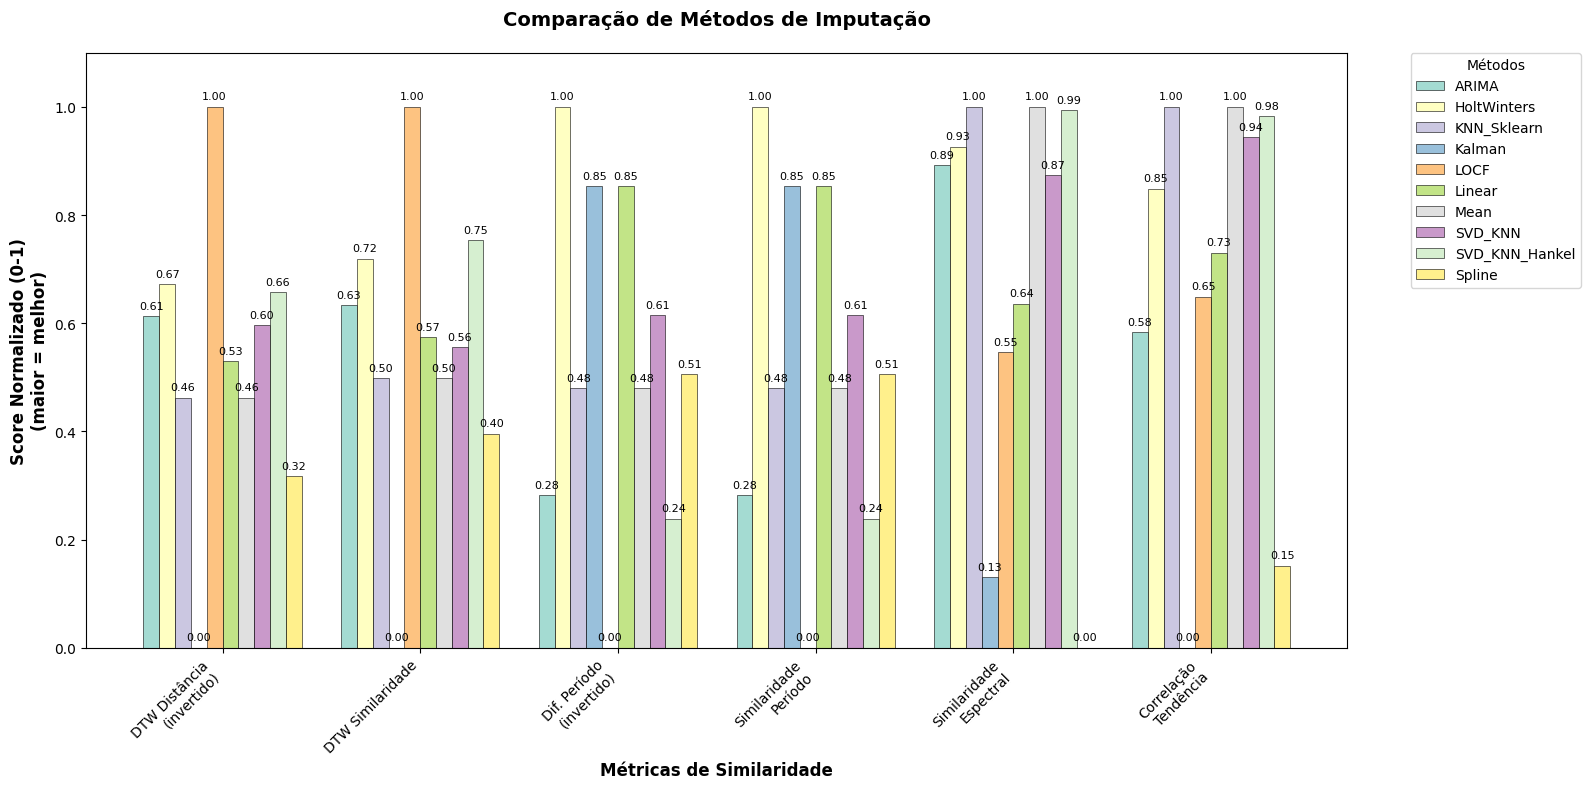


4. Métricas específicas:
Dados carregados: 10 linhas
Colunas disponíveis: ['method', 'missing_rate', 'n_series', 'dtw_distance_avg', 'dtw_similarity_avg', 'period_diff_ratio_avg', 'period_similarity_avg', 'spectral_cosine_similarity_avg', 'trend_corr_avg']
Métricas selecionadas: ['dtw_similarity_avg', 'trend_corr_avg', 'spectral_cosine_similarity_avg']


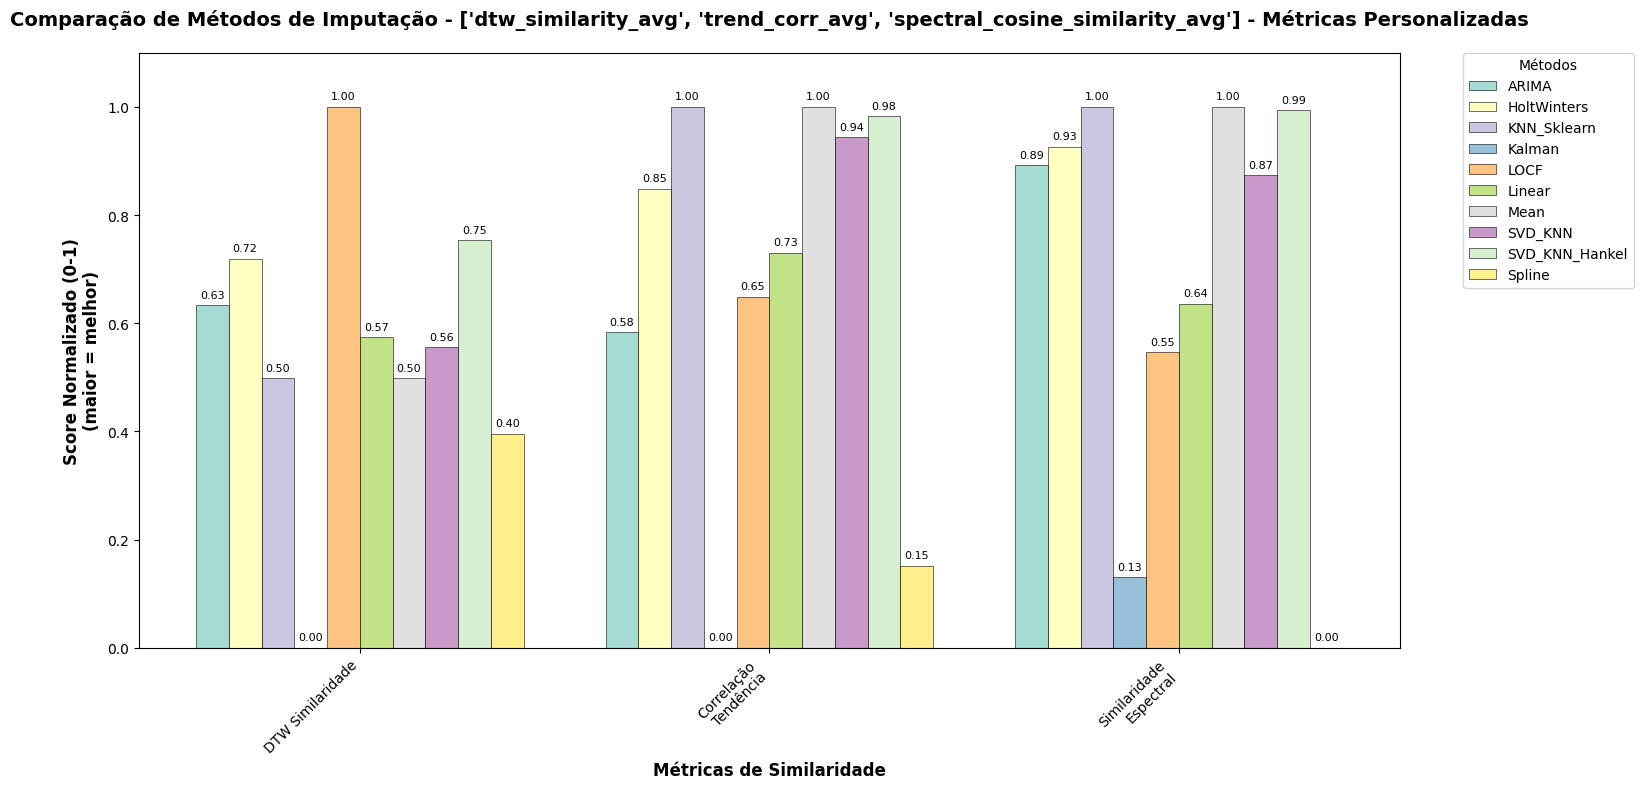

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_comparison_barchart(csv_path=OUTPUT_SIMIL_BY_RATE, 
                           metrics_to_plot='all',
                           normalization='individual',
                           group_by='method',
                           figsize=(16, 8),
                           title_suffix=""):
    """
    Plota gráfico de barras comparativo dos métodos de imputação.
    
    Parameters:
    -----------
    csv_path : str
        Caminho para o arquivo CSV com os dados agregados
    metrics_to_plot : str or list
        'all' - plota todas as métricas disponíveis
        'similarity_only' - apenas métricas de similaridade (onde maior é melhor)
        'distance_only' - apenas métricas de distância (onde menor é melhor)
        ['metric1', 'metric2'] - lista específica de métricas
    normalization : str
        'individual' - normaliza cada métrica individualmente (padrão)
        'global' - usa valores originais sem normalização
        'zscore' - normalização por z-score
    group_by : str
        'method' - agrupa por método de imputação
        'missing_rate' - agrupa por taxa de missing
    figsize : tuple
        Tamanho da figura (largura, altura)
    title_suffix : str
        Texto adicional para o título
    """
    
    # Ler os dados
    try:
        df = pd.read_csv(csv_path)
        print(f"Dados carregados: {len(df)} linhas")
        print(f"Colunas disponíveis: {list(df.columns)}")
    except Exception as e:
        print(f"Erro ao ler o arquivo {csv_path}: {e}")
        return
    
    # Verificar se existem dados
    if df.empty:
        print("DataFrame vazio. Nenhum dado para plotar.")
        return
    
    # Todas as métricas possíveis
    all_metrics = [
        'dtw_distance_avg',
        'dtw_similarity_avg', 
        'period_diff_ratio_avg',
        'period_similarity_avg',
        'spectral_cosine_similarity_avg',
        'trend_corr_avg'
    ]
    
    # Determinar quais métricas plotar
    available_metrics = [m for m in all_metrics if m in df.columns]
    
    if metrics_to_plot == 'all':
        selected_metrics = available_metrics
    elif metrics_to_plot == 'similarity_only':
        similarity_metrics = [m for m in available_metrics if 'similarity' in m or 'corr' in m]
        selected_metrics = similarity_metrics
    elif metrics_to_plot == 'distance_only':
        distance_metrics = [m for m in available_metrics if 'distance' in m or 'diff' in m or 'ratio' in m]
        selected_metrics = distance_metrics
    elif isinstance(metrics_to_plot, list):
        selected_metrics = [m for m in metrics_to_plot if m in available_metrics]
        missing = [m for m in metrics_to_plot if m not in available_metrics]
        if missing:
            print(f"Aviso: Métricas não encontradas: {missing}")
    else:
        print("Opção inválida para metrics_to_plot. Usando 'all'.")
        selected_metrics = available_metrics
    
    if not selected_metrics:
        print("Nenhuma métrica selecionada para plotar.")
        return
    
    print(f"Métricas selecionadas: {selected_metrics}")
    
    # Preparar dados para plotagem
    if group_by == 'method':
        group_col = 'method'
        x_label = 'Métricas de Similaridade'
    elif group_by == 'missing_rate':
        group_col = 'missing_rate'
        x_label = 'Métricas de Similaridade'
    else:
        group_col = 'method'
        x_label = 'Métricas de Similaridade'
    
    # Aplicar normalização
    df_plot = df.copy()
    
    if normalization == 'individual':
        # Normalização individual para cada métrica (0-1)
        for metric in selected_metrics:
            if metric in ['dtw_distance_avg', 'period_diff_ratio_avg']:
                # Inverter: menor distância/diferença = melhor
                min_val = df[metric].min()
                max_val = df[metric].max()
                if max_val > min_val:
                    df_plot[metric] = 1 - (df[metric] - min_val) / (max_val - min_val)
                else:
                    df_plot[metric] = 1.0
            else:
                # Manter: maior similaridade = melhor
                min_val = df[metric].min()
                max_val = df[metric].max()
                if max_val > min_val:
                    df_plot[metric] = (df[metric] - min_val) / (max_val - min_val)
                else:
                    df_plot[metric] = 1.0
        y_label = 'Score Normalizado (0-1)\n(maior = melhor)'
        
    elif normalization == 'zscore':
        # Normalização Z-score
        for metric in selected_metrics:
            mean_val = df[metric].mean()
            std_val = df[metric].std()
            if std_val > 0:
                df_plot[metric] = (df[metric] - mean_val) / std_val
            else:
                df_plot[metric] = 0
        y_label = 'Z-score\n(maior = melhor)'
        
    else:  # 'global' - sem normalização
        y_label = 'Valor Original'
    
    # Agrupar dados
    groups = df_plot[group_col].unique()
    
    # Calcular médias por grupo
    group_means = {}
    for group in groups:
        group_data = df_plot[df_plot[group_col] == group]
        group_means[group] = {}
        for metric in selected_metrics:
            group_means[group][metric] = group_data[metric].mean()
    
    # Criar o gráfico
    fig, ax = plt.subplots(figsize=figsize)
    
    # Configurações do gráfico
    bar_width = 0.8 / len(groups)  # Largura dinâmica baseada no número de grupos
    x_pos = np.arange(len(selected_metrics))
    colors = plt.cm.Set3(np.linspace(0, 1, len(groups)))
    
    # Plotar barras para cada grupo
    for i, group in enumerate(groups):
        values = [group_means[group][metric] for metric in selected_metrics]
        positions = x_pos + i * bar_width - (len(groups) - 1) * bar_width / 2
        
        bars = ax.bar(positions, values, bar_width, label=str(group), color=colors[i], 
                     alpha=0.8, edgecolor='black', linewidth=0.5)
        
        # Adicionar valores nas barras
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{value:.2f}', ha='center', va='bottom', fontsize=8, rotation=0)
    
    # Personalizar o gráfico
    ax.set_xlabel(x_label, fontsize=12, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=12, fontweight='bold')
    
    # Título baseado nas escolhas
    title_parts = ["Comparação de Métodos de Imputação"]
    if metrics_to_plot != 'all':
        title_parts.append(f" - {metrics_to_plot}")
    if normalization != 'individual':
        title_parts.append(f" - {normalization}")
    if title_suffix:
        title_parts.append(f" - {title_suffix}")
    
    ax.set_title(''.join(title_parts), fontsize=14, fontweight='bold', pad=20)
    
    # Configurar eixos
    ax.set_xticks(x_pos)
    
    # Nomes mais legíveis para as métricas
    metric_names = {
        'dtw_distance_avg': 'DTW Distância\n(invertido)',
        'dtw_similarity_avg': 'DTW Similaridade',
        'period_diff_ratio_avg': 'Dif. Período\n(invertido)', 
        'period_similarity_avg': 'Similaridade\nPeríodo',
        'spectral_cosine_similarity_avg': 'Similaridade\nEspectral',
        'trend_corr_avg': 'Correlação\nTendência'
    }
    
    xtick_labels = [metric_names.get(metric, metric) for metric in selected_metrics]
    ax.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=10)
    
    # Ajustar limites do eixo Y baseado na normalização
    if normalization == 'individual':
        ax.set_ylim(0, 1.1)
    elif normalization == 'zscore':
        # Encontrar o range dos dados para ajustar o eixo Y
        all_values = []
        for group_data in group_means.values():
            all_values.extend(list(group_data.values()))
        y_min, y_max = min(all_values), max(all_values)
        margin = (y_max - y_min) * 0.1
        ax.set_ylim(y_min - margin, y_max + margin)
    
    # Legenda
    legend_title = 'Métodos' if group_by == 'method' else 'Taxa Missing'
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., 
              title=legend_title, title_fontsize=10)
    
    # Remover grid
    ax.grid(False)
    
    # Ajustar layout
    plt.tight_layout()
    
    # Mostrar o gráfico
    plt.show()
    
    return group_means, selected_metrics

# Funções de conveniência para casos de uso comuns
def plot_similarity_metrics(csv_path=OUTPUT_SIMIL_BY_RATE, **kwargs):
    """Plota apenas métricas de similaridade (onde maior é melhor)"""
    return plot_comparison_barchart(csv_path, metrics_to_plot='similarity_only', 
                                  title_suffix="Métricas de Similaridade", **kwargs)

def plot_distance_metrics(csv_path=OUTPUT_SIMIL_BY_RATE, **kwargs):
    """Plota apenas métricas de distância (onde menor é melhor)"""
    return plot_comparison_barchart(csv_path, metrics_to_plot='distance_only', 
                                  title_suffix="Métricas de Distância", **kwargs)

def plot_custom_metrics(metrics_list, csv_path=OUTPUT_SIMIL_BY_RATE, **kwargs):
    """Plota uma lista personalizada de métricas"""
    return plot_comparison_barchart(csv_path, metrics_to_plot=metrics_list, 
                                  title_suffix="Métricas Personalizadas", **kwargs)

# Exemplos de uso:
if __name__ == "__main__":
    # 1. Todas as métricas (padrão)
    print("1. Todas as métricas:")
    plot_comparison_barchart()
    
    # 4. Métricas específicas
    print("\n4. Métricas específicas:")
    custom_metrics = ['dtw_similarity_avg', 'trend_corr_avg', 'spectral_cosine_similarity_avg']
    plot_custom_metrics(custom_metrics)


In [14]:
# ==========================
# Config
# ==========================
import os, re
import numpy as np
import pandas as pd

ORIGINAL_FOLDER = "../longest_interval_datasets"   # pasta dos originais (longest)
IMPUTED_FOLDER  = "../imputation_results_final_longest/imputed_datasets_all"            # folder with imputed CSVs
VALUE_COL       = "Vazao"                          # coluna do valor (bps)
ORIGINAL_SUFFIX = "_longest.csv"                   # sufixo dos originais

INVALID_LINK_SUBSTRINGS = {
    "perfsonar.restena.lu to psmp-gn-bw-lis-pt.geant.org"
}

# Bins em Mbps p/ fuzzy accuracy
BINS_MBPS = np.arange(0, 2100, 100)
LABELS = [f'{BINS_MBPS[i]}-{BINS_MBPS[i+1]}' for i in range(len(BINS_MBPS)-1)]

# ==========================
# Fuzzy accuracy helpers
# ==========================
def fuzzy_weight(distance: int) -> float:
    return {0: 1.0, 1: 0.75, 2: 0.5}.get(distance, 0.0)

def compute_fuzzy_accuracy(y_true, y_pred):
    df = pd.DataFrame({'y_test': y_true, 'y_pred': y_pred}).dropna()
    if df.empty:
        return None, 0

    df['y_test_mbps'] = df['y_test'] / 1e6
    df['y_pred_mbps'] = df['y_pred'] / 1e6

    df['true_bin'] = pd.cut(df['y_test_mbps'], bins=BINS_MBPS, labels=LABELS, right=False)
    df['pred_bin'] = pd.cut(df['y_pred_mbps'], bins=BINS_MBPS, labels=LABELS, right=False)

    label_to_index = {label: idx for idx, label in enumerate(LABELS)}
    df['true_idx'] = df['true_bin'].map(label_to_index)
    df['pred_idx'] = df['pred_bin'].map(label_to_index)

    df = df.dropna(subset=['true_idx', 'pred_idx'])
    if df.empty:
        return None, 0

    df['distance'] = (df['true_idx'].astype(int) - df['pred_idx'].astype(int)).abs()
    df['fuzzy_weight'] = df['distance'].apply(fuzzy_weight)

    return df['fuzzy_weight'].mean(), len(df)

# ==========================
# IO & parsing helpers
# ==========================
def _read_value_series(csv_path: str, value_col: str):
    """Lê CSV e retorna a série de valores (dtype float) pela coluna informada.
       Se a coluna não existir, tenta alguns aliases comuns."""
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    if value_col in df.columns:
        s = df[value_col]
    else:
        # Aliases comuns para vazão
        aliases = ("Vazao","throughput_bps","value","n_bytes","bytes")
        found = next((c for c in df.columns if c in aliases), None)
        if found is None:
            raise ValueError(f"Coluna de valor não encontrada em {os.path.basename(csv_path)}")
        s = df[found]
    s = pd.to_numeric(s, errors='coerce')
    return s

def _safe_align(y1: pd.Series, y2: pd.Series):
    """Alinha por comprimento mínimo, descartando NaNs nas mesmas posições após truncar."""
    n = int(min(len(y1), len(y2)))
    y1 = y1.iloc[:n].astype(float)
    y2 = y2.iloc[:n].astype(float)
    mask = ~(y1.isna() | y2.isna())
    return y1[mask].to_numpy(), y2[mask].to_numpy(), int(mask.sum())

def _infer_base_and_method(fname):
    """
    Extrai (base, method) de nomes como:
      base_mr20_Method(_imputed).csv
      base_Method(_imputed).csv
      base_..._mr10_Method_imputed.csv
    Retorna strings (base, method).
    """
    name = os.path.splitext(os.path.basename(fname))[0]
    # remove sufixos comuns no fim
    name = re.sub(r'_imputed$', '', name, flags=re.IGNORECASE)

    # 1) base_mrXX_method
    m = re.match(r'^(?P<base>.+?)_mr(?P<mr>\d{1,3})_(?P<method>.+)$', name, flags=re.IGNORECASE)
    if m:
        base = m.group('base')
        method = m.group('method')
        return base, method

    # 2) base_method  (sem mr)
    m = re.match(r'^(?P<base>.+?)_(?P<method>[^_]+)$', name)
    if m:
        return m.group('base'), m.group('method')

    return name


def _infer_missing_rate(filename: str):
    mr_match = re.search(r"_mr(\d{1,3})\b", filename, flags=re.IGNORECASE)
    return int(mr_match.group(1)) if mr_match else np.nan

# ==========================
# Varredura e avaliação
# ==========================
def evaluate_fuzzy_accuracy_imputations():
    results = []
    # imputed_files = [f for f in os.listdir(IMPUTED_FOLDER) if f.lower().endswith(".csv")]
    imputed_files = [
    f for f in os.listdir(IMPUTED_FOLDER)
    if f.lower().endswith(".csv")
       and not any(bad in f.lower() for bad in INVALID_LINK_SUBSTRINGS)
]

    for imp_file in sorted(imputed_files):
        imp_path = os.path.join(IMPUTED_FOLDER, imp_file)
        base, method = _infer_base_and_method(imp_file)
        missing_rate = _infer_missing_rate(imp_file)

        # Localiza original esperado
        orig_file = f"{base}{ORIGINAL_SUFFIX}"
        orig_path = os.path.join(ORIGINAL_FOLDER, orig_file)

        if not os.path.exists(orig_path):
            # Heurísticas alternativas (iguais ao seu exemplo)
            candidates = [f for f in os.listdir(ORIGINAL_FOLDER)
                          if f.endswith(ORIGINAL_SUFFIX) and f.startswith(base)]
            if candidates:
                orig_path = os.path.join(ORIGINAL_FOLDER, candidates[0])
            else:
                candidates = [f for f in os.listdir(ORIGINAL_FOLDER)
                              if f.startswith(base) and f.lower().endswith(".csv") and "_longest" in f.lower()]
                if candidates:
                    orig_path = os.path.join(ORIGINAL_FOLDER, candidates[0])
                else:
                    print(f"[skip] Original não encontrado p/ '{imp_file}' (base='{base}').")
                    continue

        try:
            y_imp = _read_value_series(imp_path, VALUE_COL)  # imputado
            y_ori = _read_value_series(orig_path, VALUE_COL) # original
        except Exception as e:
            print(f"[skip] Erro de leitura '{imp_file}': {e}")
            continue

        y_ori_a, y_imp_a, n = _safe_align(y_ori, y_imp)
        if n < 8:
            print(f"[skip] Série curta ({n}) para '{imp_file}'.")
            continue

        acc, sample_count = compute_fuzzy_accuracy(y_true=y_ori_a, y_pred=y_imp_a)
        if acc is None:
            continue

        results.append({
            "Pop": base.upper(),
            "Method": method,
            "MissingRate": missing_rate,
            "Fuzzy_Accuracy": acc * 100.0,  # %
            "Samples": sample_count,
            "ImputedFile": imp_file
        })

    return pd.DataFrame(results)

# ==========================
# Execução e agregações
# ==========================
pd.options.display.float_format = '{:.2f}'.format

df_fuzzy = evaluate_fuzzy_accuracy_imputations()

# Pivot por Pop x Method (média da fuzzy accuracy)
df_pivot = df_fuzzy.pivot_table(index="Pop", columns="Method", values="Fuzzy_Accuracy", aggfunc="mean").reset_index()

# Contagem total de amostras por Pop
df_counts = df_fuzzy.groupby("Pop")["Samples"].sum().reset_index()

# Junta e arredonda
df_result = pd.merge(df_pivot, df_counts, on="Pop", how="left").round(2)

# Linha "overall" (média das colunas numéricas exceto Pop)
mean_values = df_result.drop(columns=["Pop"]).mean(numeric_only=True)
overall_row = {**mean_values.to_dict(), "Pop": "overall"}
df_result = pd.concat([df_result, pd.DataFrame([overall_row])], ignore_index=True)

df_result.to_csv("output_fuzzy2.csv", index=False)
# (Opcional) visão por MissingRate: média por método e taxa
df_by_rate = (
    df_fuzzy
    .groupby(["MissingRate", "Method"])["Fuzzy_Accuracy"]
    .mean()
    .reset_index()
    .sort_values(["MissingRate", "Method"])
    .round(2)
)

# Exibições principais:
print("Resumo por Pop x Método (inclui linha 'overall'):")
display(df_result)

print("\nResumo por MissingRate x Método (médias):")
display(df_by_rate)


Resumo por Pop x Método (inclui linha 'overall'):


,Pop,ARIMA,HoltWinters,KNN_Sklearn,Kalman,LOCF,Linear,Mean,SVD_KNN,SVD_KNN_Hankel,Spline,Samples
0,ESMOND DATA PERFSONAR-ANKARA.ULAKBIM.GOV.TR TO...,95.33,94.83,95.87,92.17,93.40,94.31,95.87,95.72,95.82,92.49,40595.00
1,ESMOND DATA PERFSONAR-ANKARA.ULAKBIM.GOV.TR TO...,94.94,94.77,95.18,92.48,93.72,94.16,95.18,94.89,95.03,92.33,41509.00
2,ESMOND DATA PERFSONAR-SONDA.REDIRIS.ES TO PSMP...,100.00,100.00,100.00,93.81,100.00,99.61,100.00,100.00,100.00,99.63,812.00
3,ESMOND DATA PSMALL.LUT.AC.UK TO PSMP-GN-BW-VIE...,94.72,94.37,88.91,91.17,94.34,94.17,88.91,91.30,93.34,92.16,35288.00
4,ESMOND DATA PSMP-GN-BW-LIS-PT.GEANT.ORG TO PER...,96.95,97.15,97.38,96.43,96.70,96.73,97.38,97.10,97.20,96.70,40033.00
5,ESMOND DATA PSMP-GN-BW-LIS-PT.GEANT.ORG TO PER...,95.20,94.92,95.85,92.56,93.50,94.48,95.85,95.73,95.82,92.29,44116.00
6,ESMOND DATA PSMP-GN-BW-POZ-PL.GEANT.ORG TO PER...,97.04,97.46,97.70,96.74,97.24,97.01,97.70,97.11,97.34,96.87,40714.00
7,ESMOND DATA PSMP-GN-BW-POZ-PL.GEANT.ORG TO PSP...,96.84,96.60,97.11,95.11,95.24,95.61,97.11,96.69,97.07,94.14,49078.00
8,ESMOND DATA PSMP-GN-BW-VIE-AT.GEANT.ORG TO PSM...,98.70,98.60,98.71,97.03,97.87,98.28,98.71,98.71,98.71,97.14,44060.00
9,ESMOND DATA PSPMP-ANELLA.CSUC.CAT TO PSMP-GN-B...,94.79,94.59,95.19,91.94,93.53,93.64,95.19,95.09,95.13,91.95,29237.00



Resumo por MissingRate x Método (médias):


,MissingRate,Method,Fuzzy_Accuracy


In [19]:
# ==========================
# Config
# ==========================
import os, re
import numpy as np
import pandas as pd

ORIGINAL_FOLDER = "../longest_interval_datasets"   # pasta dos originais (longest)
IMPUTED_FOLDER  = "../imputation_results_final_longest/imputed_datasets_all"            # folder with imputed CSVs
VALUE_COL       = "Vazao"                          # coluna do valor (bps)
ORIGINAL_SUFFIX = "_longest.csv"                   # sufixo dos originais

INVALID_LINK_SUBSTRINGS = {
    "perfsonar.restena.lu to psmp-gn-bw-lis-pt.geant.org"
}

# Bins em Mbps p/ fuzzy accuracy
BINS_MBPS = np.arange(0, 2100, 100)
LABELS = [f'{BINS_MBPS[i]}-{BINS_MBPS[i+1]}' for i in range(len(BINS_MBPS)-1)]

# ==========================
# Fuzzy accuracy helpers
# ==========================
def _infer_missing_rate_from_text(text: str):
    """Tenta extrair mrXX de um texto qualquer (ex.: base/pop)."""
    if not isinstance(text, str):
        return np.nan
    m = re.search(r"\bmr(\d{1,3})\b", text, flags=re.IGNORECASE)
    return int(m.group(1)) if m else np.nan

def _remove_mr_from_text(text: str):
    """Remove o sufixo/pedaço _mrXX do texto para obter o 'link' limpo."""
    if not isinstance(text, str):
        return text
    # remove _mrXX ou -mrXX ou espaço-mrXX; cobre alguns formatos comuns
    cleaned = re.sub(r"(_|-|\s)?mr\d{1,3}\b", "", text, flags=re.IGNORECASE)
    # também remove duplos underscores remanescentes
    cleaned = re.sub(r"__+", "_", cleaned)
    return cleaned.strip("_- ").upper()


def fuzzy_weight(distance: int) -> float:
    return {0: 1.0, 1: 0.75, 2: 0.5}.get(distance, 0.0)

def compute_fuzzy_accuracy(y_true, y_pred):
    df = pd.DataFrame({'y_test': y_true, 'y_pred': y_pred}).dropna()
    if df.empty:
        return None, 0

    df['y_test_mbps'] = df['y_test'] / 1e6
    df['y_pred_mbps'] = df['y_pred'] / 1e6

    df['true_bin'] = pd.cut(df['y_test_mbps'], bins=BINS_MBPS, labels=LABELS, right=False)
    df['pred_bin'] = pd.cut(df['y_pred_mbps'], bins=BINS_MBPS, labels=LABELS, right=False)

    label_to_index = {label: idx for idx, label in enumerate(LABELS)}
    df['true_idx'] = df['true_bin'].map(label_to_index)
    df['pred_idx'] = df['pred_bin'].map(label_to_index)

    df = df.dropna(subset=['true_idx', 'pred_idx'])
    if df.empty:
        return None, 0

    df['distance'] = (df['true_idx'].astype(int) - df['pred_idx'].astype(int)).abs()
    df['fuzzy_weight'] = df['distance'].apply(fuzzy_weight)

    return df['fuzzy_weight'].mean(), len(df)

# ==========================
# IO & parsing helpers
# ==========================
def _read_value_series(csv_path: str, value_col: str):
    """Lê CSV e retorna a série de valores (dtype float) pela coluna informada.
       Se a coluna não existir, tenta alguns aliases comuns."""
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    if value_col in df.columns:
        s = df[value_col]
    else:
        # Aliases comuns para vazão
        aliases = ("Vazao","throughput_bps","value","n_bytes","bytes")
        found = next((c for c in df.columns if c in aliases), None)
        if found is None:
            raise ValueError(f"Coluna de valor não encontrada em {os.path.basename(csv_path)}")
        s = df[found]
    s = pd.to_numeric(s, errors='coerce')
    return s

def _safe_align(y1: pd.Series, y2: pd.Series):
    """Alinha por comprimento mínimo, descartando NaNs nas mesmas posições após truncar."""
    n = int(min(len(y1), len(y2)))
    y1 = y1.iloc[:n].astype(float)
    y2 = y2.iloc[:n].astype(float)
    mask = ~(y1.isna() | y2.isna())
    return y1[mask].to_numpy(), y2[mask].to_numpy(), int(mask.sum())

def _infer_base_and_method(fname):
    """
    Extrai (base, method) de nomes como:
      base_mr20_Method(_imputed).csv
      base_Method(_imputed).csv
      base_..._mr10_Method_imputed.csv
    Retorna strings (base, method).
    """
    name = os.path.splitext(os.path.basename(fname))[0]
    # remove sufixos comuns no fim
    name = re.sub(r'_imputed$', '', name, flags=re.IGNORECASE)

    # 1) base_mrXX_method
    m = re.match(r'^(?P<base>.+?)_mr(?P<mr>\d{1,3})_(?P<method>.+)$', name, flags=re.IGNORECASE)
    if m:
        base = m.group('base')
        method = m.group('method')
        return base, method

    # 2) base_method  (sem mr)
    m = re.match(r'^(?P<base>.+?)_(?P<method>[^_]+)$', name)
    if m:
        return m.group('base'), m.group('method')

    return name



# ==========================
# Varredura e avaliação
# ==========================
def evaluate_fuzzy_accuracy_imputations():
    results = []
    # imputed_files = [f for f in os.listdir(IMPUTED_FOLDER) if f.lower().endswith(".csv")]
    imputed_files = [
    f for f in os.listdir(IMPUTED_FOLDER)
    if f.lower().endswith(".csv")
       and not any(bad in f.lower() for bad in INVALID_LINK_SUBSTRINGS)
]

    for imp_file in sorted(imputed_files):
        imp_path = os.path.join(IMPUTED_FOLDER, imp_file)
        base, method = _infer_base_and_method(imp_file)
        missing_rate = _infer_missing_rate_from_text(imp_file)

        # Localiza original esperado
        orig_file = f"{base}{ORIGINAL_SUFFIX}"
        orig_path = os.path.join(ORIGINAL_FOLDER, orig_file)

        if not os.path.exists(orig_path):
            # Heurísticas alternativas (iguais ao seu exemplo)
            candidates = [f for f in os.listdir(ORIGINAL_FOLDER)
                          if f.endswith(ORIGINAL_SUFFIX) and f.startswith(base)]
            if candidates:
                orig_path = os.path.join(ORIGINAL_FOLDER, candidates[0])
            else:
                candidates = [f for f in os.listdir(ORIGINAL_FOLDER)
                              if f.startswith(base) and f.lower().endswith(".csv") and "_longest" in f.lower()]
                if candidates:
                    orig_path = os.path.join(ORIGINAL_FOLDER, candidates[0])
                else:
                    print(f"[skip] Original não encontrado p/ '{imp_file}' (base='{base}').")
                    continue

        try:
            y_imp = _read_value_series(imp_path, VALUE_COL)  # imputado
            y_ori = _read_value_series(orig_path, VALUE_COL) # original
        except Exception as e:
            print(f"[skip] Erro de leitura '{imp_file}': {e}")
            continue

        y_ori_a, y_imp_a, n = _safe_align(y_ori, y_imp)
        if n < 8:
            print(f"[skip] Série curta ({n}) para '{imp_file}'.")
            continue

        acc, sample_count = compute_fuzzy_accuracy(y_true=y_ori_a, y_pred=y_imp_a)
        if acc is None:
            continue

        results.append({
            "Pop": base.upper(),
            "Method": method,
            "MissingRate": missing_rate,
            "Fuzzy_Accuracy": acc * 100.0,  # %
            "Samples": sample_count,
            "ImputedFile": imp_file,
        })

    return pd.DataFrame(results)

# ==========================
# Execução e agregações
# ==========================
pd.options.display.float_format = '{:.2f}'.format

df_fuzzy = evaluate_fuzzy_accuracy_imputations()

# Pivot por Pop x Method (média da fuzzy accuracy)
df_pivot = df_fuzzy.pivot_table(index="Pop", columns="Method", values="Fuzzy_Accuracy", aggfunc="mean").reset_index()

# Contagem total de amostras por Pop
df_counts = df_fuzzy.groupby("Pop")["Samples"].sum().reset_index()

# Junta e arredonda
df_result = pd.merge(df_pivot, df_counts, on="Pop", how="left").round(2)

# Linha "overall" (média das colunas numéricas exceto Pop)
mean_values = df_result.drop(columns=["Pop"]).mean(numeric_only=True)
overall_row = {**mean_values.to_dict(), "Pop": "overall"}
df_result = pd.concat([df_result, pd.DataFrame([overall_row])], ignore_index=True)

df_result.to_csv("output_fuzzy2.csv", index=False)
# (Opcional) visão por MissingRate: média por método e taxa
df_by_rate = (
    df_fuzzy
    .groupby(["MissingRate", "Method"])["Fuzzy_Accuracy"]
    .mean()
    .reset_index()
    .sort_values(["MissingRate", "Method"])
    .round(2)
)

# Exibições principais:
print("Resumo por Pop x Método (inclui linha 'overall'):")
display(df_result)

print("\nResumo por MissingRate x Método (médias):")
display(df_by_rate)


Resumo por Pop x Método (inclui linha 'overall'):


,Pop,ARIMA,HoltWinters,KNN_Sklearn,Kalman,LOCF,Linear,Mean,SVD_KNN,SVD_KNN_Hankel,Spline,Samples
0,ESMOND DATA PERFSONAR-ANKARA.ULAKBIM.GOV.TR TO...,95.33,94.83,95.87,92.17,93.40,94.31,95.87,95.72,95.82,92.49,40595.00
1,ESMOND DATA PERFSONAR-ANKARA.ULAKBIM.GOV.TR TO...,94.94,94.77,95.18,92.48,93.72,94.16,95.18,94.89,95.03,92.33,41509.00
2,ESMOND DATA PERFSONAR-SONDA.REDIRIS.ES TO PSMP...,100.00,100.00,100.00,93.81,100.00,99.61,100.00,100.00,100.00,99.63,812.00
3,ESMOND DATA PSMALL.LUT.AC.UK TO PSMP-GN-BW-VIE...,94.72,94.37,88.91,91.17,94.34,94.17,88.91,91.30,93.34,92.16,35288.00
4,ESMOND DATA PSMP-GN-BW-LIS-PT.GEANT.ORG TO PER...,96.95,97.15,97.38,96.43,96.70,96.73,97.38,97.10,97.20,96.70,40033.00
5,ESMOND DATA PSMP-GN-BW-LIS-PT.GEANT.ORG TO PER...,95.20,94.92,95.85,92.56,93.50,94.48,95.85,95.73,95.82,92.29,44116.00
6,ESMOND DATA PSMP-GN-BW-POZ-PL.GEANT.ORG TO PER...,97.04,97.46,97.70,96.74,97.24,97.01,97.70,97.11,97.34,96.87,40714.00
7,ESMOND DATA PSMP-GN-BW-POZ-PL.GEANT.ORG TO PSP...,96.84,96.60,97.11,95.11,95.24,95.61,97.11,96.69,97.07,94.14,49078.00
8,ESMOND DATA PSMP-GN-BW-VIE-AT.GEANT.ORG TO PSM...,98.70,98.60,98.71,97.03,97.87,98.28,98.71,98.71,98.71,97.14,44060.00
9,ESMOND DATA PSPMP-ANELLA.CSUC.CAT TO PSMP-GN-B...,94.79,94.59,95.19,91.94,93.53,93.64,95.19,95.09,95.13,91.95,29237.00



Resumo por MissingRate x Método (médias):


,MissingRate,Method,Fuzzy_Accuracy


In [28]:
df_result[df_result["Pop"]=="overall"].to_numpy()

array([['overall', 96.451, 96.32900000000001, 96.19000000000001, 93.944,
        95.554, 95.8, 96.19000000000001, 96.23400000000001,
        96.54599999999999, 94.57000000000001, 36544.2]], dtype=object)

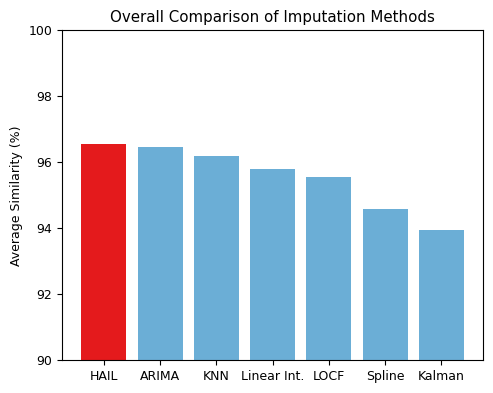

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'Method': ['ARIMA','KNN','Kalman','LOCF','Linear Int.','HAIL','Spline'],
    'MeanScore': [96.451, 96.19000000000001, 93.944,
        95.554, 95.8, 
        96.54599999999999, 94.57000000000001]
}

df = pd.DataFrame(data).sort_values('MeanScore', ascending=False)

plt.figure(figsize=(5,4))
bars = plt.bar(df['Method'], df['MeanScore'], color=['#6baed6' if m!='HAIL' else '#e41a1c' for m in df['Method']])
plt.ylabel("Average Fuzzy Accuracy (%)")
plt.xticks(rotation=0)
plt.title("Overall Comparison of Imputation Methods")
plt.ylim(90, 100)
plt.tight_layout()
plt.show()


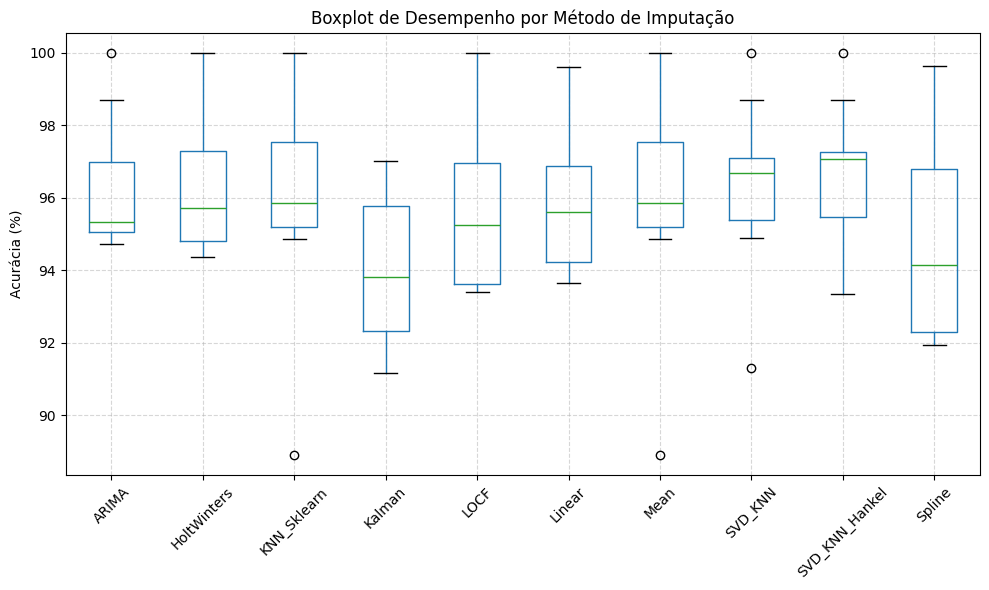

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

raw = """Pop,ARIMA,HoltWinters,KNN_Sklearn,Kalman,LOCF,Linear,Mean,SVD_KNN,SVD_KNN_Hankel,Spline,Samples
ESMOND DATA PERFSONAR-ANKARA.ULAKBIM.GOV.TR TO PSMP-GN-BW-LIS-PT.GEANT.ORG 10-24-2023,95.33,94.83,95.87,92.17,93.4,94.31,95.87,95.72,95.82,92.49,40595.0
ESMOND DATA PERFSONAR-ANKARA.ULAKBIM.GOV.TR TO PSMP-GN-BW-POZ-PL.GEANT.ORG 10-24-2023,94.94,94.77,95.18,92.48,93.72,94.16,95.18,94.89,95.03,92.33,41509.0
ESMOND DATA PERFSONAR-SONDA.REDIRIS.ES TO PSMP-GN-BW-LIS-PT.GEANT.ORG 10-24-2023,100.0,100.0,100.0,93.81,100.0,99.61,100.0,100.0,100.0,99.63,812.0
ESMOND DATA PERFSONAR.RESTENA.LU TO PSMP-GN-BW-LIS-PT.GEANT.ORG 10-23-2023,95.35,95.73,94.88,94.01,95.54,95.7,94.88,96.72,97.21,94.6,41353.0
ESMOND DATA PSMALL.LUT.AC.UK TO PSMP-GN-BW-VIE-AT.GEANT.ORG 10-24-2023,94.72,94.37,88.91,91.17,94.34,94.17,88.91,91.3,93.34,92.16,35288.0
ESMOND DATA PSMP-GN-BW-LIS-PT.GEANT.ORG TO PERFSONAR-ANKARA.ULAKBIM.GOV.TR 10-24-2023,96.95,97.15,97.38,96.43,96.7,96.73,97.38,97.1,97.2,96.7,40033.0
ESMOND DATA PSMP-GN-BW-LIS-PT.GEANT.ORG TO PERFSONAR.RESTENA.LU 10-24-2023,95.2,94.92,95.85,92.56,93.5,94.48,95.85,95.73,95.82,92.29,44116.0
ESMOND DATA PSMP-GN-BW-POZ-PL.GEANT.ORG TO PERFSONAR-ANKARA.ULAKBIM.GOV.TR 10-24-2023,97.04,97.46,97.7,96.74,97.24,97.01,97.7,97.11,97.34,96.87,40714.0
ESMOND DATA PSMP-GN-BW-POZ-PL.GEANT.ORG TO PSPMP-ANELLA.CSUC.CAT 10-24-2023,96.84,96.6,97.11,95.11,95.24,95.61,97.11,96.69,97.07,94.14,49078.0
ESMOND DATA PSMP-GN-BW-VIE-AT.GEANT.ORG TO PSMALL.LUT.AC.UK 10-24-2023,98.7,98.6,98.71,97.03,97.87,98.28,98.71,98.71,98.71,97.14,44060.0
ESMOND DATA PSPMP-ANELLA.CSUC.CAT TO PSMP-GN-BW-POZ-PL.GEANT.ORG 10-24-2023,94.79,94.59,95.19,91.94,93.53,93.64,95.19,95.09,95.13,91.95,29237.0
overall,96.3509090909091,96.27454545454545,96.07090909090908,93.95,95.55272727272728,95.7909090909091,96.07090909090908,96.2781818181818,96.60636363636364,94.57272727272726,36981.36363636364
"""

df = pd.read_csv(StringIO(raw))
df = df.drop(columns=["Pop", "Samples"])
df = df.drop(df[df.index == len(df)-1].index)  # remove linha "overall"

plt.figure(figsize=(10,6))
df.boxplot()
plt.title("Boxplot de Desempenho por Método de Imputação")
plt.ylabel("Acurácia (%)")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


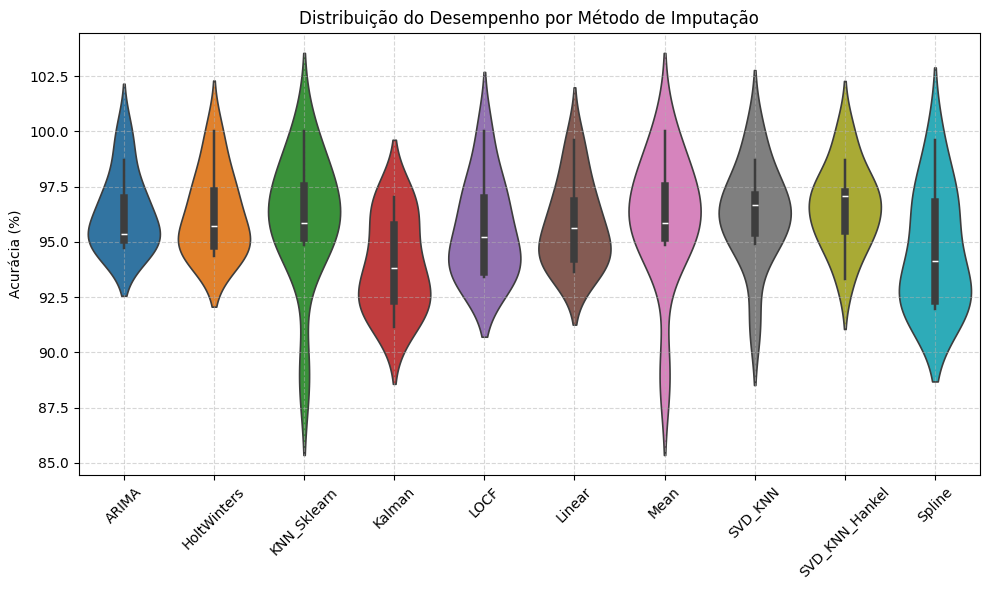

In [32]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.violinplot(data=df, inner='box', linewidth=1.2)
plt.title("Distribuição do Desempenho por Método de Imputação")
plt.ylabel("Acurácia (%)")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


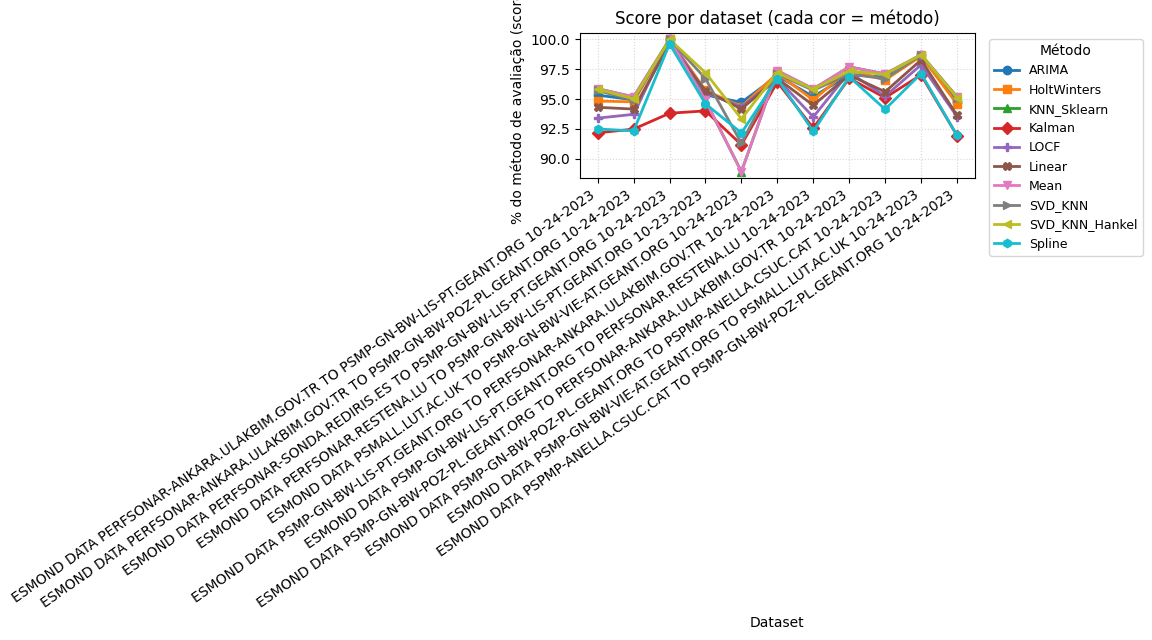

In [28]:
# -*- coding: utf-8 -*-
# Linha por método; X = dataset, Y = score (%) — como no exemplo
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
from pathlib import Path

RAW = """Pop,ARIMA,HoltWinters,KNN_Sklearn,Kalman,LOCF,Linear,Mean,SVD_KNN,SVD_KNN_Hankel,Spline,Samples
ESMOND DATA PERFSONAR-ANKARA.ULAKBIM.GOV.TR TO PSMP-GN-BW-LIS-PT.GEANT.ORG 10-24-2023,95.33,94.83,95.87,92.17,93.4,94.31,95.87,95.72,95.82,92.49,40595.0
ESMOND DATA PERFSONAR-ANKARA.ULAKBIM.GOV.TR TO PSMP-GN-BW-POZ-PL.GEANT.ORG 10-24-2023,94.94,94.77,95.18,92.48,93.72,94.16,95.18,94.89,95.03,92.33,41509.0
ESMOND DATA PERFSONAR-SONDA.REDIRIS.ES TO PSMP-GN-BW-LIS-PT.GEANT.ORG 10-24-2023,100.0,100.0,100.0,93.81,100.0,99.61,100.0,100.0,100.0,99.63,812.0
ESMOND DATA PERFSONAR.RESTENA.LU TO PSMP-GN-BW-LIS-PT.GEANT.ORG 10-23-2023,95.35,95.73,94.88,94.01,95.54,95.7,94.88,96.72,97.21,94.6,41353.0
ESMOND DATA PSMALL.LUT.AC.UK TO PSMP-GN-BW-VIE-AT.GEANT.ORG 10-24-2023,94.72,94.37,88.91,91.17,94.34,94.17,88.91,91.3,93.34,92.16,35288.0
ESMOND DATA PSMP-GN-BW-LIS-PT.GEANT.ORG TO PERFSONAR-ANKARA.ULAKBIM.GOV.TR 10-24-2023,96.95,97.15,97.38,96.43,96.7,96.73,97.38,97.1,97.2,96.7,40033.0
ESMOND DATA PSMP-GN-BW-LIS-PT.GEANT.ORG TO PERFSONAR.RESTENA.LU 10-24-2023,95.2,94.92,95.85,92.56,93.5,94.48,95.85,95.73,95.82,92.29,44116.0
ESMOND DATA PSMP-GN-BW-POZ-PL.GEANT.ORG TO PERFSONAR-ANKARA.ULAKBIM.GOV.TR 10-24-2023,97.04,97.46,97.7,96.74,97.24,97.01,97.7,97.11,97.34,96.87,40714.0
ESMOND DATA PSMP-GN-BW-POZ-PL.GEANT.ORG TO PSPMP-ANELLA.CSUC.CAT 10-24-2023,96.84,96.6,97.11,95.11,95.24,95.61,97.11,96.69,97.07,94.14,49078.0
ESMOND DATA PSMP-GN-BW-VIE-AT.GEANT.ORG TO PSMALL.LUT.AC.UK 10-24-2023,98.7,98.6,98.71,97.03,97.87,98.28,98.71,98.71,98.71,97.14,44060.0
ESMOND DATA PSPMP-ANELLA.CSUC.CAT TO PSMP-GN-BW-POZ-PL.GEANT.ORG 10-24-2023,94.79,94.59,95.19,91.94,93.53,93.64,95.19,95.09,95.13,91.95,29237.0
overall,96.3509090909091,96.27454545454545,96.07090909090908,93.95,95.55272727272728,95.7909090909091,96.07090909090908,96.2781818181818,96.60636363636364,94.57272727272726,36981.36363636364
"""

# 1) Ler e ir para formato longo
df = pd.read_csv(StringIO(RAW)).rename(columns={'Pop': 'dataset'})
for c in df.columns:
    if c != 'dataset':
        df[c] = pd.to_numeric(df[c], errors='coerce')

df = df[df['dataset'] != 'overall'].copy()  # remove a linha 'overall'

method_cols = [c for c in df.columns if c not in ('dataset', 'Samples')]
df_long = df.melt(id_vars='dataset', value_vars=method_cols,
                  var_name='method', value_name='score')

# (opcional) ordenar datasets por número de amostras
# df = df.sort_values('Samples')
# order = df['dataset'].tolist()

# 2) Pivot para linhas por método (como no gráfico de exemplo)
pivot = df_long.pivot(index='dataset', columns='method', values='score')

# 3) Plot
plt.figure(figsize=(11.5, 6.5))
markers = ['o','s','^','D','P','X','v','>','<','h','*']  # marcadores distintos
colors = plt.cm.tab10.colors                              # paleta legível

for i, m in enumerate(pivot.columns):
    plt.plot(pivot.index, pivot[m],
             marker=markers[i % len(markers)],
             linewidth=2,
             markersize=6,
             label=m,
             color=colors[i % len(colors)])

plt.ylabel('% do método de avaliação (score)')
plt.xlabel('Dataset')
plt.title('Score por dataset (cada cor = método)')
plt.xticks(rotation=35, ha='right')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(title='Método', bbox_to_anchor=(1.02, 1), loc='upper left', ncol=1, fontsize=9)
plt.tight_layout()

Path('figures').mkdir(exist_ok=True)
plt.savefig('figures/lines_por_dataset_metodos.png', dpi=300)
plt.savefig('figures/lines_por_dataset_metodos.pdf')
plt.show()


### Trying to evaluate real data imputed without ground truth (with  WD / JSD)

In [38]:
# ==========================
# Config
# ==========================
ORIGINAL_FOLDER = "../longest_interval_datasets"  # folder with originals
IMPUTED_FOLDER  = "../imputation_results_final_longest/imputed_datasets_all"  # folder with imputed CSVs
VALUE_COL       = "Vazao"                       # column to compare (valor)
ORIGINAL_SUFFIX = "_longest.csv"                # how original files end
OUTPUT_CSV      = "rmse_nrmse_wd_jsd_summary.csv"  # output summary (um por imputado)
NORMALIZATION   = "range"                       # "range" or "std" for NRMSE
# ==========================

import os, re, warnings
import numpy as np
import pandas as pd

# (Opcional) SciPy para WD. Se não houver, cai no fallback por quantis.
try:
    from scipy.stats import wasserstein_distance as scipy_wd
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False
    warnings.warn("SciPy não encontrado; WD usará fallback por quantis.")

# Nomes possíveis de colunas
TIMESTAMP_COLS = ("Data", "timestamp", "time", "Datetime", "date", "Date")
VALUE_COLS     = (VALUE_COL, "throughput_bps", "value", "n_bytes", "bytes")

# ==========================
# Helpers de nomes/arquivos
# ==========================
def _infer_base_and_method(fname):
    """
    Extrai (base, method) de nomes como:
      base_mr20_Method(_imputed).csv
      base_Method(_imputed).csv
      base_..._mr10_Method_imputed.csv
    Retorna (base, method). Se não conseguir, method='Unknown'.
    """
    name = os.path.splitext(os.path.basename(fname))[0]
    name = re.sub(r'_imputed$', '', name, flags=re.IGNORECASE)

    m = re.match(r'^(?P<base>.+?)_mr(?P<mr>\d{1,3})_(?P<method>.+)$', name, flags=re.IGNORECASE)
    if m:
        return m.group('base'), m.group('method')

    m = re.match(r'^(?P<base>.+?)_(?P<method>[^_]+)$', name)
    if m:
        return m.group('base'), m.group('method')

    return name, "Unknown"

def _pick_first_existing(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    # tenta case-insensitive
    lc = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lc:
            return lc[c.lower()]
    return None

def _read_series(csv_path):
    """
    Lê CSV e retorna DataFrame com colunas ['ts','y'].
    - ts: timestamp (se existir coluna de tempo), senão índice numérico.
    - y: série de valores (VALUE_COLS).
    """
    df = pd.read_csv(csv_path)
    vcol = _pick_first_existing(df, VALUE_COLS)
    if vcol is None:
        raise ValueError(f"Nenhuma coluna de valor encontrada em {csv_path}. Possíveis: {VALUE_COLS}")
    tcol = _pick_first_existing(df, TIMESTAMP_COLS)

    if tcol is not None:
        s = df[[tcol, vcol]].dropna().rename(columns={tcol: "ts", vcol: "y"})
        with pd.option_context('mode.chained_assignment', None):
            try:
                s["ts"] = pd.to_datetime(s["ts"])
            except Exception:
                # mantém como string/num se não for datetime parseável
                pass
    else:
        s = df[[vcol]].dropna().rename(columns={vcol: "y"})
        s["ts"] = np.arange(len(s), dtype=float)

    return s[["ts", "y"]]

def _align_on_ts(df_a, df_b):
    """
    Tenta alinhar por 'ts'. Se não der match suficiente, alinha por comprimento mínimo.
    Retorna (y_a, y_b) como np.array.
    """
    try:
        merged = pd.merge(df_a, df_b, on="ts", how="inner", suffixes=("_a", "_b"))
        if len(merged) >= 2:
            return merged["y_a"].to_numpy(), merged["y_b"].to_numpy()
    except Exception:
        pass
    # fallback
    y_a = df_a["y"].to_numpy()
    y_b = df_b["y"].to_numpy()
    n = min(len(y_a), len(y_b))
    return y_a[:n], y_b[:n]

# ==========================
# Métricas (RMSE/NRMSE)
# ==========================
def _rmse(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = ~(np.isnan(a) | np.isnan(b))
    if not np.any(mask):
        return np.nan
    return float(np.sqrt(np.mean((a[mask] - b[mask])**2)))

def _nrmse(a, b, mode="range"):
    """
    mode='range': divide por (max(a)-min(a))
    mode='std'  : divide por std(a)
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = ~(np.isnan(a) | np.isnan(b))
    if not np.any(mask):
        return np.nan
    rmse = np.sqrt(np.mean((a[mask] - b[mask])**2))
    if mode == "std":
        denom = np.nanstd(a[mask])
    else:
        denom = (np.nanmax(a[mask]) - np.nanmin(a[mask]))
    if denom is None or denom == 0 or not np.isfinite(denom):
        return np.nan
    return float(rmse / denom)

# ==========================
# Métricas WD / JSD
# ==========================
def _freedman_diaconis_bins(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 2:
        return 1
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    if iqr <= 0:
        return max(1, int(np.sqrt(x.size)))
    h = 2 * iqr * x.size ** (-1/3)
    if h <= 0:
        return max(1, int(np.sqrt(x.size)))
    bins = int(np.ceil((x.max() - x.min()) / h))
    return max(1, bins)

def _hist_probs(x, bins="fd", fixed_bins=50, clip_range=None):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if clip_range is not None:
        lo, hi = clip_range
        if lo is not None:
            x = x[x >= lo]
        if hi is not None:
            x = x[x <= hi]
    if x.size == 0:
        return np.array([1.0])
    if bins == "fd":
        n_bins = _freedman_diaconis_bins(x)
    else:
        n_bins = int(fixed_bins)
    hist, _ = np.histogram(x, bins=n_bins, density=False)
    p = hist.astype(float)
    s = p.sum()
    return (p / s) if s > 0 else np.full_like(p, 1.0 / len(p), dtype=float)

def _kl_divergence(p, q, eps=1e-12):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    p = np.clip(p, eps, 1.0); p /= p.sum()
    q = np.clip(q, eps, 1.0); q /= q.sum()
    return float(np.sum(p * np.log(p / q)))

def jensen_shannon_divergence(p, q, eps=1e-12, return_distance=False):
    p = np.asarray(p, dtype=float); p /= p.sum()
    q = np.asarray(q, dtype=float); q /= q.sum()
    m = 0.5 * (p + q)
    jsd = 0.5 * _kl_divergence(p, m, eps) + 0.5 * _kl_divergence(q, m, eps)
    if return_distance:
        return jsd, float(np.sqrt(jsd))
    return jsd

def wasserstein_distance_1d(x, y):
    x = np.asarray(x, dtype=float); x = x[np.isfinite(x)]
    y = np.asarray(y, dtype=float); y = y[np.isfinite(y)]
    if x.size == 0 or y.size == 0:
        return np.nan
    if _HAS_SCIPY:
        return float(scipy_wd(x, y))
    # Fallback via quantis (equivalente em 1D)
    xs = np.sort(x); ys = np.sort(y)
    u = np.linspace(0, 1, num=max(xs.size, ys.size), endpoint=True)
    qx = np.quantile(xs, u, method="linear")
    qy = np.quantile(ys, u, method="linear")
    return float(np.mean(np.abs(qx - qy)))

# ==========================
# Loop pelos imputados
# ==========================
# Config de JSD
BINS_MODE   = "fd"   # "fd" (Freedman–Diaconis) ou "fixed"
FIXED_BINS  = 50
CLIP_RANGE  = None   # ex.: (0, None)
SMOOTH_EPS  = 1e-12

imputed_files = [f for f in os.listdir(IMPUTED_FOLDER) if f.lower().endswith(".csv")]
results = []

for imp_file in sorted(imputed_files):
    imp_path = os.path.join(IMPUTED_FOLDER, imp_file)
    base, method = _infer_base_and_method(imp_file)

    # extrai missing_rate do nome: _mr10_, _mr30_, etc.
    mr_match = re.search(r"_mr(\d{1,3})\b", imp_file, flags=re.IGNORECASE)
    missing_rate = int(mr_match.group(1)) if mr_match else np.nan

    # tenta {base}{ORIGINAL_SUFFIX}
    orig_file = f"{base}{ORIGINAL_SUFFIX}"
    orig_path = os.path.join(ORIGINAL_FOLDER, orig_file)

    if not os.path.exists(orig_path):
        # procura quem começa com base e termina com ORIGINAL_SUFFIX
        cands = [f for f in os.listdir(ORIGINAL_FOLDER)
                 if f.endswith(ORIGINAL_SUFFIX) and f.startswith(base)]
        if cands:
            orig_path = os.path.join(ORIGINAL_FOLDER, cands[0])
        else:
            # último fallback: {base}_longest*.csv
            cands = [f for f in os.listdir(ORIGINAL_FOLDER)
                     if f.startswith(base) and f.lower().endswith(".csv") and "_longest" in f]
            if cands:
                orig_path = os.path.join(ORIGINAL_FOLDER, cands[0])
            else:
                print(f"[skip] Original não encontrado p/ imputado '{imp_file}' (base='{base}').")
                continue

    try:
        df_o = _read_series(orig_path)
        df_i = _read_series(imp_path)
    except Exception as e:
        print(f"[skip] Erro ao ler '{imp_file}': {e}")
        continue

    # Alinhar por timestamp quando possível (senão por comprimento mínimo)
    y_ori, y_imp = _align_on_ts(df_o, df_i)
    n = min(len(y_ori), len(y_imp))
    if n < 2:
        print(f"[skip] Muito poucos pontos alinhados em '{imp_file}' (n={n}).")
        continue

    # Métricas
    rmse = _rmse(y_ori, y_imp)
    nrmse = _nrmse(y_ori, y_imp, mode=NORMALIZATION)

    wd = wasserstein_distance_1d(y_ori, y_imp)

    p = _hist_probs(y_ori, bins=("fd" if BINS_MODE == "fd" else "fixed"),
                    fixed_bins=FIXED_BINS, clip_range=CLIP_RANGE)
    q = _hist_probs(y_imp, bins=("fd" if BINS_MODE == "fd" else "fixed"),
                    fixed_bins=FIXED_BINS, clip_range=CLIP_RANGE)

    # Garante mesmo tamanho para JSD
    k = max(len(p), len(q))
    if len(p) != k:
        p = np.interp(np.linspace(0, 1, k), np.linspace(0, 1, len(p)), p); p = np.maximum(p, 0); p /= p.sum()
    if len(q) != k:
        q = np.interp(np.linspace(0, 1, k), np.linspace(0, 1, len(q)), q); q = np.maximum(q, 0); q /= q.sum()

    jsd, js_dist = jensen_shannon_divergence(p, q, eps=SMOOTH_EPS, return_distance=True)

    results.append({
        "dataset_base": os.path.splitext(os.path.basename(orig_path))[0].replace(ORIGINAL_SUFFIX.replace(".csv",""), ""),
        "imputed_file": imp_file,
        "original_file": os.path.basename(orig_path),
        "method": method,
        "missing_rate": missing_rate,
        "n": int(n),
        "rmse": rmse,
        "nrmse": nrmse,
        "nrmse_mode": NORMALIZATION,
        "wd": wd,
        "jsd": jsd,
        "js_distance": js_dist,
        "bins_mode": BINS_MODE,
        "bins_used": int(k)
    })

summary_df = pd.DataFrame(results).sort_values(["dataset_base","method","missing_rate"], na_position="last").reset_index(drop=True)
print(summary_df.head())
summary_df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved: {OUTPUT_CSV}  | rows={len(summary_df)}")

# ==========================
# (Opcional) Agregado por método e missing_rate
# ==========================
summary_df["missing_rate"] = pd.to_numeric(summary_df["missing_rate"], errors="coerce")
agg_df = (
    summary_df
    .groupby(["method", "missing_rate", "nrmse_mode"], dropna=False)
    .agg(
        rmse_avg=("rmse", "mean"),
        nrmse_avg=("nrmse", "mean"),
        wd_avg=("wd", "mean"),
        jsd_avg=("jsd", "mean"),
        js_distance_avg=("js_distance", "mean")
    )
    .reset_index()
    .sort_values(["method","missing_rate"])
)
agg_df.to_csv("wd_jsd_by_method_missingrate.csv", index=False)
print(f"Saved: wd_jsd_by_method_missingrate.csv  | rows={len(agg_df)}")


                                        dataset_base  \
0  esmond data perfsonar-ankara.ulakbim.gov.tr to...   
1  esmond data perfsonar-ankara.ulakbim.gov.tr to...   
2  esmond data perfsonar-ankara.ulakbim.gov.tr to...   
3  esmond data perfsonar-ankara.ulakbim.gov.tr to...   
4  esmond data perfsonar-ankara.ulakbim.gov.tr to...   

                                        imputed_file  \
0  esmond data perfsonar-ankara.ulakbim.gov.tr to...   
1  esmond data perfsonar-ankara.ulakbim.gov.tr to...   
2  esmond data perfsonar-ankara.ulakbim.gov.tr to...   
3  esmond data perfsonar-ankara.ulakbim.gov.tr to...   
4  esmond data perfsonar-ankara.ulakbim.gov.tr to...   

                                       original_file       method  \
0  esmond data perfsonar-ankara.ulakbim.gov.tr to...        ARIMA   
1  esmond data perfsonar-ankara.ulakbim.gov.tr to...        ARIMA   
2  esmond data perfsonar-ankara.ulakbim.gov.tr to...        ARIMA   
3  esmond data perfsonar-ankara.ulakbim.gov.tr to.

#### Relation RMSE X periodicity 

#### DTW Analysis (fidelity with original)

#### FAM

### Forecasting/Prediction Evaluation

#### RMSE and NRMSE ARIMA and GRU bar graph

Salvar os resultados em CSV pra ficar mais fácil de plotar

In [41]:
import json
import pandas as pd
import numpy as np
import re

# ==========================
# Configurações
# ==========================
JSON_FILE = "../evaluation_rmse_mae.json"
OUTPUT_CSV = "prediction_metrics_gru_summary_gru.csv"
PREDICTION_METHOD = "gru"

# ==========================
# Leitura do JSON
# ==========================
with open(JSON_FILE, "r", encoding="utf-8") as f:
    data = json.load(f)

rows = []

# ==========================
# Extração dos valores
# ==========================
for file_name, content in data.items():
    # Extrai método de imputação
    parts = file_name.split("_")
    if len(parts) > 3:
        imputation_method = "_".join(parts[2:-1])
    else:
        imputation_method = parts[-2] if len(parts) >= 2 else "unknown"

    rmse = content.get("rmse", np.nan)
    mae = content.get("mae", np.nan)

    # Range opcional (para cálculo do NRMSE)
    data_range = content.get("range", None)
    nrmse = rmse / data_range if (data_range and data_range != 0) else np.nan

    rows.append({
        "file": file_name,
        "imputation_method": imputation_method,
        "prediction_method": PREDICTION_METHOD,
        "rmse": rmse,
        "mae": mae,
        "nrmse": nrmse
    })

# ==========================
# Cria DataFrame
# ==========================
df = pd.DataFrame(rows)

# Calcula estatísticas gerais
mean_rmse = df["rmse"].mean()
std_rmse = df["rmse"].std()
mean_mae = df["mae"].mean()
std_mae = df["mae"].std()
mean_nrmse = df["nrmse"].mean()
std_nrmse = df["nrmse"].std()

# Adiciona linha de resumo
summary_row = pd.DataFrame([{
    "file": "MEAN_STD_SUMMARY",
    "imputation_method": "ALL",
    "prediction_method": PREDICTION_METHOD,
    "rmse": f"{mean_rmse:.4f} ± {std_rmse:.4f}",
    "mae": f"{mean_mae:.4f} ± {std_mae:.4f}",
    "nrmse": f"{mean_nrmse:.4f} ± {std_nrmse:.4f}"
}])

df_final = pd.concat([df, summary_row], ignore_index=True)

# ==========================
# Salva CSV
# ==========================
df_final.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

print(f"Arquivo salvo em: {OUTPUT_CSV}")
print(df_final.tail(5))


Arquivo salvo em: prediction_metrics_gru_summary_gru.csv
                                                  file imputation_method  \
117  esmond data psmp-gn-bw-poz-pl.geant.org to per...           SVD_KNN   
118  esmond data psmp-gn-bw-poz-pl.geant.org to psp...              Mean   
119  esmond data psmp-gn-bw-lis-pt.geant.org to per...             ARIMA   
120  esmond data psmp-gn-bw-lis-pt.geant.org to per...       HoltWinters   
121                                   MEAN_STD_SUMMARY               ALL   

    prediction_method                             rmse  \
117               gru                      58930624.74   
118               gru                      38334414.23   
119               gru                      53705811.28   
120               gru                      58473080.31   
121               gru  101137348.9981 ± 107811957.1571   

                               mae      nrmse  
117                    15418862.93        NaN  
118                    24915861.59       

In [4]:
CSV_PATH = "prediction_metrics_gru_summary_arima.csv"  # caminho do CSV

Mapeamento dos links para números:
 1 -> perfsonar-ankara.ulakbim.gov.tr to psmp-gn-bw-lis-pt.geant.org
 2 -> perfsonar-sonda.rediris.es to psmp-gn-bw-lis-pt.geant.org
 3 -> psmp-gn-bw-lis-pt.geant.org to perfsonar-ankara.ulakbim.gov.tr
 4 -> psmp-gn-bw-poz-pl.geant.org to pspmp-anella.csuc.cat
 5 -> pspmp-anella.csuc.cat to psmp-gn-bw-poz-pl.geant.org
 6 -> psmp-gn-bw-vie-at.geant.org to psmall.lut.ac.uk
 7 -> psmp-gn-bw-poz-pl.geant.org to perfsonar-ankara.ulakbim.gov.tr
 8 -> psmall.lut.ac.uk to psmp-gn-bw-vie-at.geant.org
 9 -> psmp-gn-bw-lis-pt.geant.org to perfsonar.restena.lu
10 -> perfsonar-ankara.ulakbim.gov.tr to psmp-gn-bw-poz-pl.geant.org


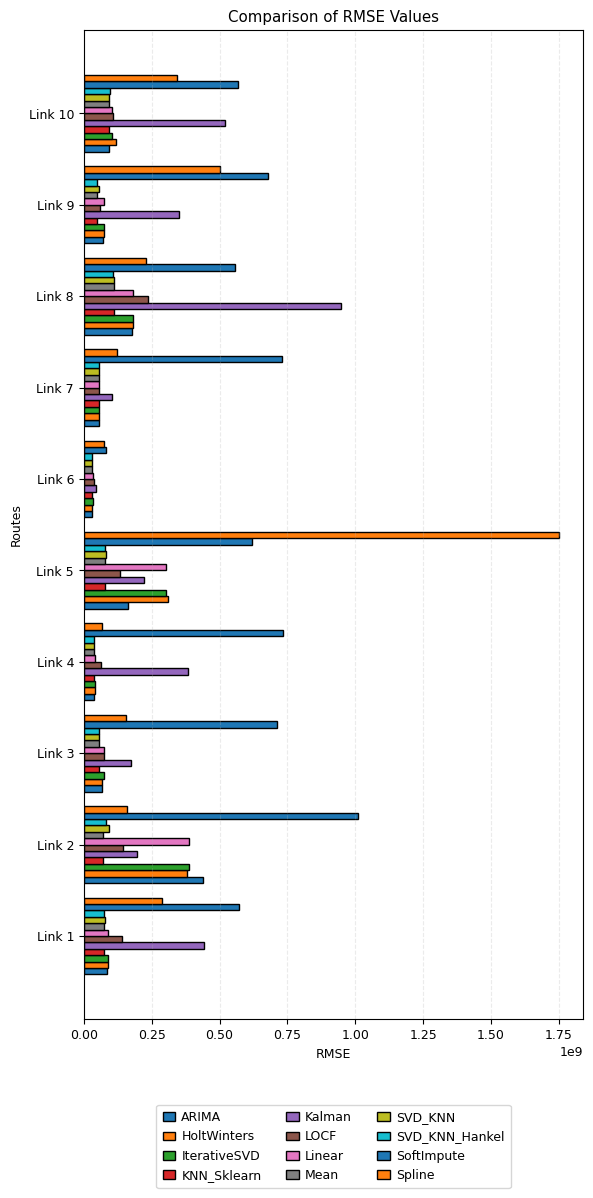

In [6]:
# ==========================
# Configuração (edite aqui)
# ==========================
METRIC = "rmse"                       # "rmse" ou "mae"
EXCLUDE_METHODS = []                  # ex.: ["Kalman", "LOCF"]
USE_NUMERIC_LABELS = True             # usar rótulos numéricos (Link 1..N) no eixo Y
LABEL_PREFIX = "Link"                 # prefixo quando USE_NUMERIC_LABELS=True
TITLE = "Comparison of RMSE Values"   # título do gráfico
EDGE_COLOR = "black"                  # contorno das barras
BAR_WIDTH = 0.07                  # largura de cada barra (deslocamento entre métodos)
FONT_SIZE = 9                         # tamanho base da fonte
LEGEND_NCOL = 3                       # número de colunas na legenda

# ==========================
# Código
# ==========================
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
def extract_link_label(file_str: str) -> str:
    """
    Extrai o nome do link seguindo a lógica:
        arr = file.split(" ")
        arr[2] + " " + arr[3] + " " + arr[4]
    Também:
      - Remove prefixos 'esmond data' e espaços extras.
      - Evita erro se o split tiver menos de 5 partes.
    """
    if not isinstance(file_str, str):
        file_str = str(file_str)

    parts = file_str.split(" ")

    # Garante que tenha elementos suficientes
    if len(parts) >= 5:
        return f"{parts[2]} {parts[3]} {parts[4]}"
    elif len(parts) >= 3:
        return " ".join(parts[2:])  # fallback
    else:
        return s  # fallback final


# 1) Ler CSV
df = pd.read_csv(CSV_PATH)

# Validações
required_cols = {"file","imputation_method","prediction_method","rmse","mae"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"CSV não contém as colunas obrigatórias: {sorted(missing)}")

# Limpeza básica
for c in ["file","imputation_method","prediction_method"]:
    df[c] = df[c].astype(str).str.strip()

metric_col = METRIC.lower()
if metric_col not in ["rmse","mae"]:
    raise ValueError("METRIC deve ser 'rmse' ou 'mae'.")

# === Tratamento do nome do link solicitado ===
df["link_label"] = df["file"].map(extract_link_label)

# Ordem estável dos links pela primeira aparição
links_order = list(dict.fromkeys(df["link_label"].tolist()))
link_to_num = {lk: i+1 for i, lk in enumerate(links_order)}

# 2) Agregar por link_label e imputation_method (média se houver múltiplos prediction_method)
agg = (df
       .groupby(["link_label","imputation_method"], as_index=False)[metric_col]
       .mean())

# Excluir métodos, se solicitado
if EXCLUDE_METHODS:
    agg = agg[~agg["imputation_method"].isin(EXCLUDE_METHODS)]

# Métodos em ordem estável (alfabética para reprodutibilidade)
methods = sorted(agg["imputation_method"].unique())
if len(methods) == 0:
    raise ValueError("Nenhum método de imputação após filtragem. Verifique EXCLUDE_METHODS.")

# Pivot para facilitar o plot
pivot = (agg
         .pivot(index="link_label", columns="imputation_method", values=metric_col)
         .reindex(index=links_order, columns=methods))

# Vetores para plot
n_links = len(links_order)
n_methods = len(methods)
index = np.arange(n_links)

# Rótulos no eixo Y
if USE_NUMERIC_LABELS:
    y_labels = [f"{LABEL_PREFIX} {link_to_num[lk]}" for lk in links_order]
else:
    y_labels = links_order

# === Plot — barras horizontais agrupadas (no estilo do seu exemplo) ===
plt.rcParams.update({"font.size": FONT_SIZE})
fig, ax = plt.subplots(figsize=(6,12))
# fig, ax = plt.subplots(figsize=(max(8, 2 + 0.6*n_methods), max(4, 0.45*n_links + 2)))

for i, m in enumerate(methods):
    vals = pivot[m].values  # em ordem de links_order
    ax.barh(index + i*BAR_WIDTH, vals, BAR_WIDTH, label=m, edgecolor=EDGE_COLOR)

# Centraliza os y-ticks no meio do bloco de métodos
ax.set_yticks(index + (n_methods - 1)*BAR_WIDTH/2)
ax.set_yticklabels(y_labels)

# Eixos e título
ax.set_xlabel(METRIC.upper())
ax.set_ylabel("Routes")
ax.set_title(TITLE)

# Grade suave no eixo X
ax.grid(axis="x", alpha=0.25, linestyle="--", linewidth=0.8)

# Legenda única embaixo (estilo parecido com seu snippet)
ax.legend(
    markerscale=0.8,
    bbox_to_anchor=(0.5, -0.08),
    loc="upper center",
    fontsize=FONT_SIZE,
    frameon=True,
    borderpad=0.5,
    ncol=min(LEGEND_NCOL, len(methods)),
    handlelength=1.0,
    handletextpad=0.5
)

# Imprimir mapeamento numérico -> nome do link (útil se USE_NUMERIC_LABELS=True)
if USE_NUMERIC_LABELS:
    print("Mapeamento dos links para números:")
    for lk in links_order:
        print(f"{link_to_num[lk]:>2} -> {lk}")

plt.tight_layout()
plt.show()


#### DTW Analysis (fidelity with original)

In [7]:
import os
import numpy as np
import pandas as pd
from pathlib import Path

# ==========================
# CONFIG
# ==========================
PREDICTIONS_FOLDER = Path("predictions_gru")     # pasta com os CSVs gerados
OUTPUT_FILE = "gru_metrics_summary.csv"          # CSV de saída
VALUE_COLS = ("original", "prediction")
ENCODINGS_TRY = ("utf-8", "latin-1", "utf-16")

# ==========================
# MÉTRICAS
# ==========================
def rmse(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if not np.any(mask):
        return np.nan
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2))

def mae(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if not np.any(mask):
        return np.nan
    return np.mean(np.abs(y_true[mask] - y_pred[mask]))

def nrmse(y_true, y_pred, mode="range"):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if not np.any(mask):
        return np.nan
    denom = (np.max(y_true[mask]) - np.min(y_true[mask])) if mode == "range" else np.std(y_true[mask])
    return rmse(y_true[mask], y_pred[mask]) / denom if denom != 0 else np.nan

def mape(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred) | (y_true == 0))
    if not np.any(mask):
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def r2_score(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if not np.any(mask):
        return np.nan
    ss_res = np.sum((y_true[mask] - y_pred[mask]) ** 2)
    ss_tot = np.sum((y_true[mask] - np.mean(y_true[mask])) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

def read_csv_any(path: Path):
    last_err = None
    for enc in ENCODINGS_TRY:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception as e:
            last_err = e
    for enc in ENCODINGS_TRY:
        try:
            return pd.read_csv(path, encoding=enc, sep=';')
        except Exception as e:
            last_err = e
    raise last_err

# ==========================
# EXECUÇÃO
# ==========================
def evaluate_predictions(folder=PREDICTIONS_FOLDER, output_file=OUTPUT_FILE):
    results = []
    folder = Path(folder)
    csv_files = list(folder.glob("*.csv"))

    if not csv_files:
        print(f"Nenhum CSV encontrado em {folder}")
        return

    for csv_path in csv_files:
        try:
            df = read_csv_any(csv_path)
        except Exception as e:
            print(f"[ERRO] Falha ao ler {csv_path}: {e}")
            continue

        if not all(c in df.columns for c in VALUE_COLS):
            print(f"[WARN] Colunas 'original' e 'prediction' não encontradas em {csv_path}")
            continue

        y_true = pd.to_numeric(df["original"], errors="coerce").to_numpy()
        y_pred = pd.to_numeric(df["prediction"], errors="coerce").to_numpy()

        metrics = {
            "file": csv_path.name,
            "rmse": rmse(y_true, y_pred),
            "mae": mae(y_true, y_pred),
            "nrmse_range": nrmse(y_true, y_pred, mode="range"),
            "nrmse_std": nrmse(y_true, y_pred, mode="std"),
            "mape": mape(y_true, y_pred),
            "r2": r2_score(y_true, y_pred),
            "n_samples": len(df)
        }
        results.append(metrics)
        print(f"[OK] {csv_path.name}  RMSE={metrics['rmse']:.2f}  MAE={metrics['mae']:.2f}")

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by="rmse").reset_index(drop=True)
    results_df.to_csv(output_file, index=False)
    print(f"\nResumo salvo em: {output_file}")
    print(results_df.head())

# Execute
if __name__ == "__main__":
    evaluate_predictions()


[OK] esmond data perfsonar-sonda.rediris.es to psmp-gn-bw-lis-pt.geant.org 10-24-2023_6h_SVD_KNN_Hankel_imputed.csv_gru.csv  RMSE=215473887.38  MAE=103608028.31
[OK] esmond data psmp-gn-bw-lis-pt.geant.org to perfsonar.restena.lu 10-24-2023_6h_Mean_imputed.csv_gru.csv  RMSE=57750168.65  MAE=45506607.04
[OK] esmond data psmp-gn-bw-poz-pl.geant.org to pspmp-anella.csuc.cat 10-24-2023_6h_ARIMA_imputed.csv_gru.csv  RMSE=45733807.64  MAE=30842592.32
[OK] esmond data perfsonar-ankara.ulakbim.gov.tr to psmp-gn-bw-poz-pl.geant.org 10-24-2023_6h_HoltWinters_imputed.csv_gru.csv  RMSE=125459500.54  MAE=84246971.88
[OK] esmond data psmp-gn-bw-vie-at.geant.org to psmall.lut.ac.uk 10-24-2023_6h_Spline_imputed.csv_gru.csv  RMSE=37537196.27  MAE=26284040.88
[OK] esmond data psmp-gn-bw-poz-pl.geant.org to perfsonar-ankara.ulakbim.gov.tr 10-24-2023_6h_HoltWinters_imputed.csv_gru.csv  RMSE=57983500.52  MAE=16802506.44
[OK] esmond data psmp-gn-bw-lis-pt.geant.org to perfsonar.restena.lu 10-24-2023_6h_Kalm

/tmp/ipykernel_50283/2587973301.py:49: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  ts = pd.to_datetime(df[ts_col], errors="coerce", dayfirst=True)
/tmp/ipykernel_50283/2587973301.py:54: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  s = s.resample("6H").mean()
/tmp/ipykernel_50283/2587973301.py:49: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  ts = pd.to_datetime(df[ts_col], errors="coerce", dayfirst=True)
/tmp/ipykernel_50283/2587973301.py:54: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  s = s.resample("6H").mean()
/tmp/ipykernel_50283/2587973301.py:49: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=F

DTW vs original salvo em dtw_vs_original_gru.png


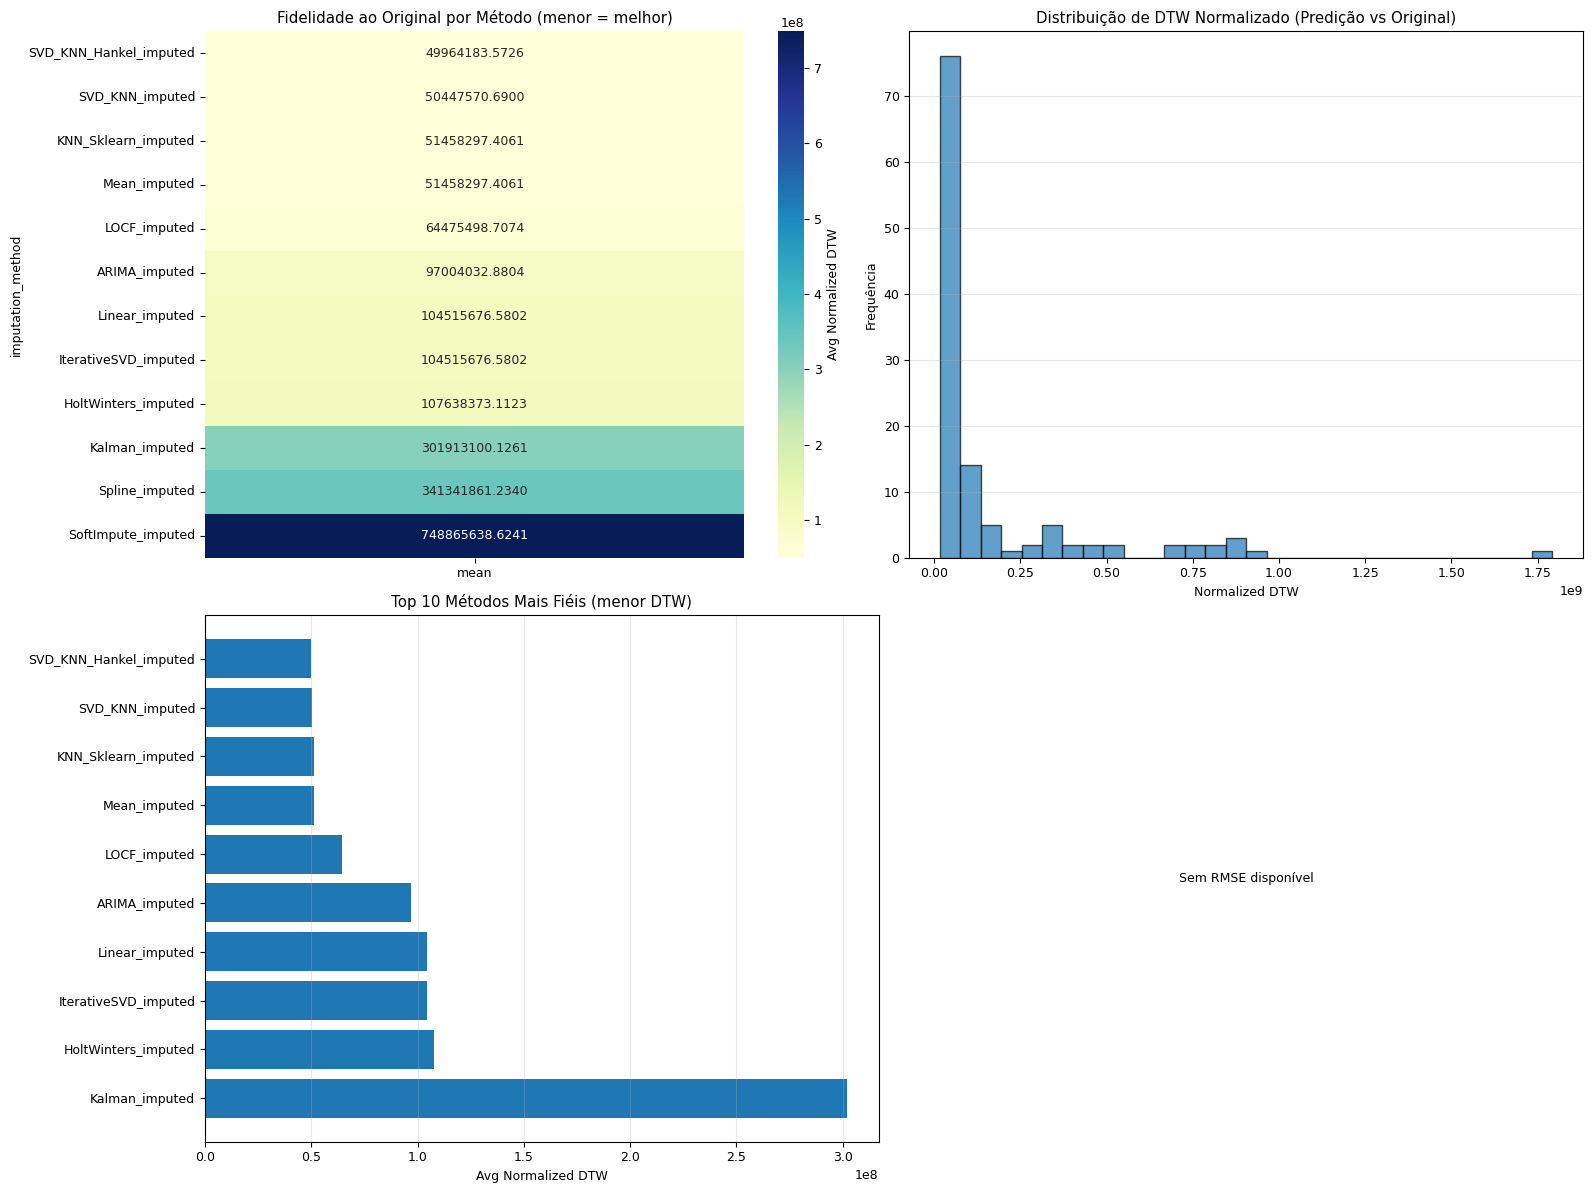

In [10]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.spatial.distance import euclidean
from fastdtw import fastdtw

# ==============================
# CONFIGURAÇÕES
# ==============================
PREDICTIONS_FOLDER = Path("predictions_gru")
ORIGINALS_FOLDER = Path("../aggregated_6h_datasets")
VALUE_COLS = ("Vazao", "throughput_bps", "value", "n_bytes", "bytes")
TIMESTAMP_COLS = ("Data", "timestamp", "time", "Datetime", "date", "Date")

# ==============================
# FUNÇÕES AUXILIARES
# ==============================
def _slugify(s: str) -> str:
    s = s.lower().strip()
    s = s.replace(" -> ", " ")
    return re.sub(r'[^a-z0-9._\- ]+', '', s)

def read_series(csv_path: Path, value_cols=VALUE_COLS, timestamp_cols=TIMESTAMP_COLS):
    """Lê um CSV e retorna pd.Series (valor indexado por datetime, se disponível)."""
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        warnings.warn(f"Falha lendo {csv_path}: {e}")
        return None

    val_col = next((c for c in value_cols if c in df.columns), None)
    ts_col = next((c for c in timestamp_cols if c in df.columns), None)

    if val_col is None:
        num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        if not num_cols:
            warnings.warn(f"Nenhuma coluna numérica em {csv_path}")
            return None
        val_col = num_cols[0]

    s = df[val_col].astype(float)

    if ts_col is not None:
        ts = pd.to_datetime(df[ts_col], errors="coerce", dayfirst=True)
        valid = ts.notna()
        s = pd.Series(s[valid].values, index=ts[valid]).sort_index()

    if isinstance(s.index, pd.DatetimeIndex):
        s = s.resample("6H").mean()

    return s.dropna()


def find_original_series(pred_file: Path, originals_folder: Path = ORIGINALS_FOLDER):
    """Tenta localizar o CSV original correspondente."""
    base_name = pred_file.name.split("_6h_")[0]
    slug_base = _slugify(base_name)

    for csv in originals_folder.rglob("*.csv"):
        if slug_base in _slugify(csv.name):
            s = read_series(csv)
            if s is not None and len(s) > 0:
                return s, csv
    return None, None


# ==============================
# ANÁLISE DTW vs ORIGINAL
# ==============================
def analyze_dtw_vs_original(predictions_folder=PREDICTIONS_FOLDER, save_plot="dtw_vs_original_gru.png"):
    """Analisa DTW das predições GRU vs originais e gera plots e resumo."""
    results = []

    pred_files = sorted(predictions_folder.glob("*_6h_*_gru.csv"))
    if not pred_files:
        print("Nenhum arquivo de predição encontrado.")
        return None

    for pred_path in pred_files:
        try:
            df_pred = pd.read_csv(pred_path)
            pred_vals = df_pred.select_dtypes(include=[np.number]).iloc[:, 0].dropna().values
        except Exception as e:
            warnings.warn(f"Falha lendo {pred_path}: {e}")
            continue

        method_match = re.search(r"_6h_(.+?)\.csv_gru\.csv$", pred_path.name)
        imputation_method = method_match.group(1) if method_match else "Unknown"

        ref_series, ref_path = find_original_series(pred_path, ORIGINALS_FOLDER)
        if ref_series is None:
            results.append({
                "filename": pred_path.name,
                "imputation_method": imputation_method,
                "ref_found": False,
                "dtw_distance": np.nan,
                "normalized_dtw": np.nan
            })
            continue

        ref_vals = ref_series.values.astype(float)
        n = len(pred_vals)
        if len(ref_vals) >= n:
            ref_segment = ref_vals[-n:]
        else:
            pred_vals = pred_vals[-len(ref_vals):]
            ref_segment = ref_vals

        try:
            dist, _ = fastdtw(pred_vals.reshape(-1, 1), ref_segment.reshape(-1, 1), dist=euclidean)
            norm = dist / len(pred_vals)
        except Exception as e:
            warnings.warn(f"DTW falhou em {pred_path.name}: {e}")
            dist, norm = np.nan, np.nan

        results.append({
            "filename": pred_path.name,
            "imputation_method": imputation_method,
            "ref_found": True,
            "ref_path": str(ref_path),
            "dtw_distance": dist,
            "normalized_dtw": norm,
            "sequence_length": len(pred_vals)
        })

    dtw_df = pd.DataFrame(results)
    valid = dtw_df.dropna(subset=["normalized_dtw"])
    if valid.empty:
        print("Sem dados válidos para DTW.")
        return dtw_df

    summary = (valid.groupby("imputation_method")["normalized_dtw"]
               .agg(["count", "mean", "std", "min", "max"])
               .sort_values("mean").round(4))

    # ==============================
    # PLOTS
    # ==============================
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1) Heatmap média por método
    sns.heatmap(summary[["mean"]], annot=True, fmt=".4f", cmap="YlGnBu",
                cbar_kws={"label": "Avg Normalized DTW"}, ax=axes[0, 0])
    axes[0, 0].set_title("Fidelidade ao Original por Método (menor = melhor)")

    # 2) Histograma global
    axes[0, 1].hist(valid["normalized_dtw"], bins=30, edgecolor="black", alpha=0.7)
    axes[0, 1].set_xlabel("Normalized DTW")
    axes[0, 1].set_ylabel("Frequência")
    axes[0, 1].set_title("Distribuição de DTW Normalizado (Predição vs Original)")
    axes[0, 1].grid(axis="y", alpha=0.3)

    # 3) Top 10 métodos
    top10 = summary.head(10)
    axes[1, 0].barh(top10.index, top10["mean"])
    axes[1, 0].invert_yaxis()
    axes[1, 0].set_xlabel("Avg Normalized DTW")
    axes[1, 0].set_title("Top 10 Métodos Mais Fiéis (menor DTW)")
    axes[1, 0].grid(axis="x", alpha=0.3)

    # 4) Correlação DTW x RMSE (se existir coluna rmse)
    if "rmse" in df_pred.columns:
        try:
            merged = valid[["imputation_method", "normalized_dtw"]].copy()
            merged["rmse"] = df_pred["rmse"].mean()  # valor médio, placeholder
            axes[1, 1].scatter(merged["normalized_dtw"], merged["rmse"], alpha=0.6, s=50)
            axes[1, 1].set_xlabel("Normalized DTW")
            axes[1, 1].set_ylabel("RMSE")
            axes[1, 1].set_title("DTW (vs original) x RMSE")
            axes[1, 1].grid(alpha=0.3)
        except Exception:
            axes[1, 1].text(0.5, 0.5, "Sem RMSE disponível", ha="center", va="center")
    else:
        axes[1, 1].axis("off")
        axes[1, 1].text(0.5, 0.5, "Sem RMSE disponível", ha="center", va="center")

    plt.tight_layout()
    plt.savefig(save_plot, dpi=300, bbox_inches="tight")
    print(f"DTW vs original salvo em {save_plot}")

    return dtw_df, summary, fig

dtw_df, summary, fig = analyze_dtw_vs_original(
    predictions_folder=Path("predictions_gru"),
    save_plot="dtw_vs_original_gru.png"
)


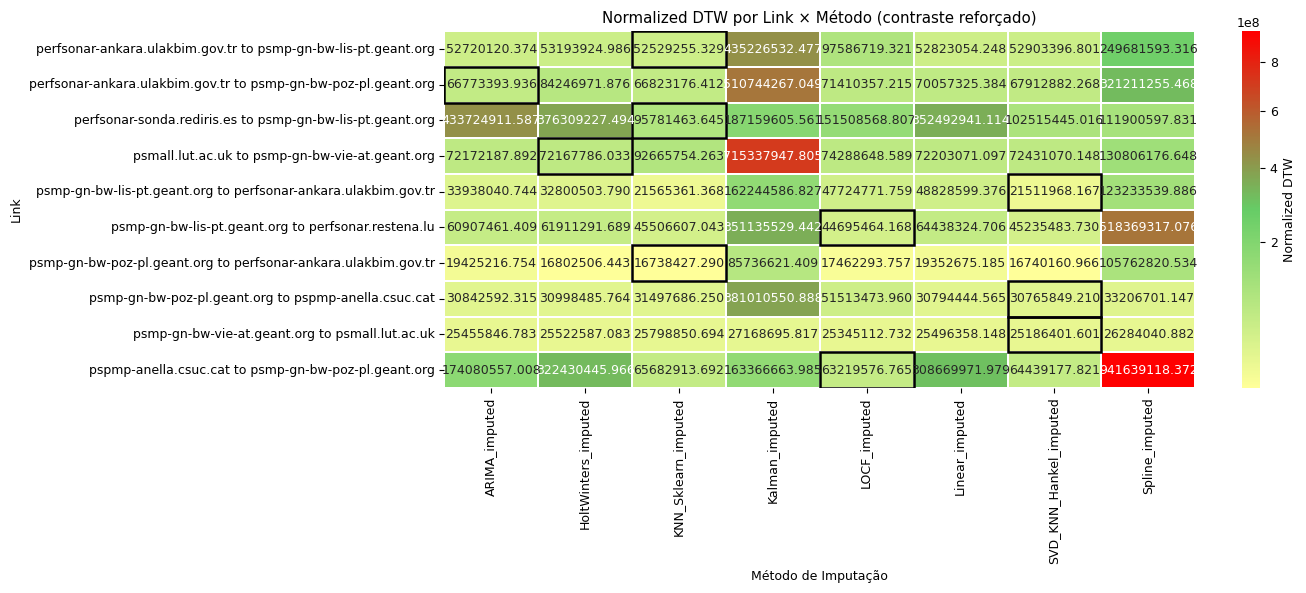

In [49]:
# ==============================
# HEATMAP: LINK × MÉTODO com contraste reforçado
# ==============================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, PowerNorm, BoundaryNorm

# ---- Config contraste ----
EMPHASIS = "power"        # opções: "power" | "quantile" | "row_zscore"
GAMMA = 0.55              # < 1 expande diferenças em valores baixos (para "power")
N_BINS = 13               # nº de bins para quantis (para "quantile")
ANNOTATE = True           # mostrar valores nas células
FMT = ".3f"               # casas decimais
CLIP_QUANTILES = (0.01, 0.99)  # clipping global para reduzir outliers extremos

# ---- Colormap amarelo -> verde -> vermelho (vermelho = pior/maior DTW)
colors = ["#FFFF99", "#66CC66", "#FF0000"]
custom_cmap = LinearSegmentedColormap.from_list("YellowGreenRed", colors)

# --- base: heatmap_data já criado (link × método) ---
mat = heatmap_data.copy()

# Clipping global opcional para robustez
vals = mat.to_numpy().astype(float)
finite = np.isfinite(vals)
if finite.any():
    qlow, qhigh = np.quantile(vals[finite], CLIP_QUANTILES)
    vals = np.clip(vals, qlow, qhigh)
    mat = pd.DataFrame(vals, index=mat.index, columns=mat.columns)

# ----- Modos de ênfase -----
norm = None
if EMPHASIS == "power":
    # Expande o contraste em valores pequenos (diferenças ficam mais visíveis)
    vmin = np.nanmin(mat.to_numpy())
    vmax = np.nanmax(mat.to_numpy())
    norm = PowerNorm(gamma=GAMMA, vmin=vmin, vmax=vmax)

elif EMPHASIS == "quantile":
    # Discretiza por quantis para criar “degraus” de cor bem definidos
    flat = mat.to_numpy().ravel()
    flat = flat[np.isfinite(flat)]
    qs = np.quantile(flat, np.linspace(0, 1, N_BINS + 1))
    # Evita limites repetidos (caso muitos valores iguais)
    qs = np.unique(qs)
    if len(qs) < 3:  # fallback
        vmin = np.nanmin(mat.to_numpy()); vmax = np.nanmax(mat.to_numpy())
        norm = PowerNorm(gamma=GAMMA, vmin=vmin, vmax=vmax)
    else:
        norm = BoundaryNorm(qs, custom_cmap.N, clip=True)

elif EMPHASIS == "row_zscore":
    # Enfatiza diferenças RELATIVAS por link (z-score por linha)
    # bom quando cada link tem escala diferente
    mat = mat.sub(mat.mean(axis=1), axis=0).div(mat.std(axis=1).replace(0, np.nan), axis=0)
    # para z-score, use diverging se quiser, mas manteremos a paleta custom
    vmin = np.nanpercentile(mat.to_numpy(), 1)
    vmax = np.nanpercentile(mat.to_numpy(), 99)
    norm = None  # manter linear; clipping já aplicado acima
    # Observação: aqui "vermelho" = z-score alto (pior que média da linha)

# ----- Plot -----
plt.figure(figsize=(14, max(6, len(mat) * 0.25)))
ax = sns.heatmap(
    mat,
    annot=False if not ANNOTATE else True,
    fmt=FMT,
    cmap=custom_cmap,
    norm=norm,
    cbar_kws={"label": "Normalized DTW" if EMPHASIS != "row_zscore" else "Z-score (por link)"},
    linewidths=0.3
)
plt.title("Normalized DTW por Link × Método (contraste reforçado)")
plt.xlabel("Método de Imputação")
plt.ylabel("Link")
plt.tight_layout()

# ----- Destaque do melhor método por link (menor valor em cada linha) -----
# contorna a célula com menor DTW por linha
for i, (idx, row) in enumerate(heatmap_data.iterrows()):
    # usa heatmap_data original para escolher o mínimo "real", independente da transformação de EMPHASIS
    arr = row.to_numpy(dtype=float)
    if np.isfinite(arr).any():
        j = np.nanargmin(arr)
        ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="black", linewidth=1.8))

plt.show()
# opcional: plt.savefig("heatmap_dtw_link_method_contraste.png", dpi=300, bbox_inches="tight")


In [50]:
from scipy.stats import wilcoxon
import numpy as np

# Extrair valores dos dois métodos
seu_metodo = heatmap_data['SVD_KNN_Hankel_imputed'].values
knn_sklearn = heatmap_data['KNN_Sklearn_imputed'].values

# Teste de Wilcoxon (não-paramétrico)
stat, p_value = wilcoxon(seu_metodo, knn_sklearn, alternative='less')

print(f"Estatística: {stat}")
print(f"P-valor: {p_value}")
print(f"Melhoria média: {np.mean(knn_sklearn - seu_metodo):.4f}")
print(f"% de links onde seu método é melhor: {(seu_metodo < knn_sklearn).mean()*100:.1f}%")

Estatística: 21.0
P-valor: 0.2783203125
Melhoria média: 1494113.8335
% de links onde seu método é melhor: 60.0%


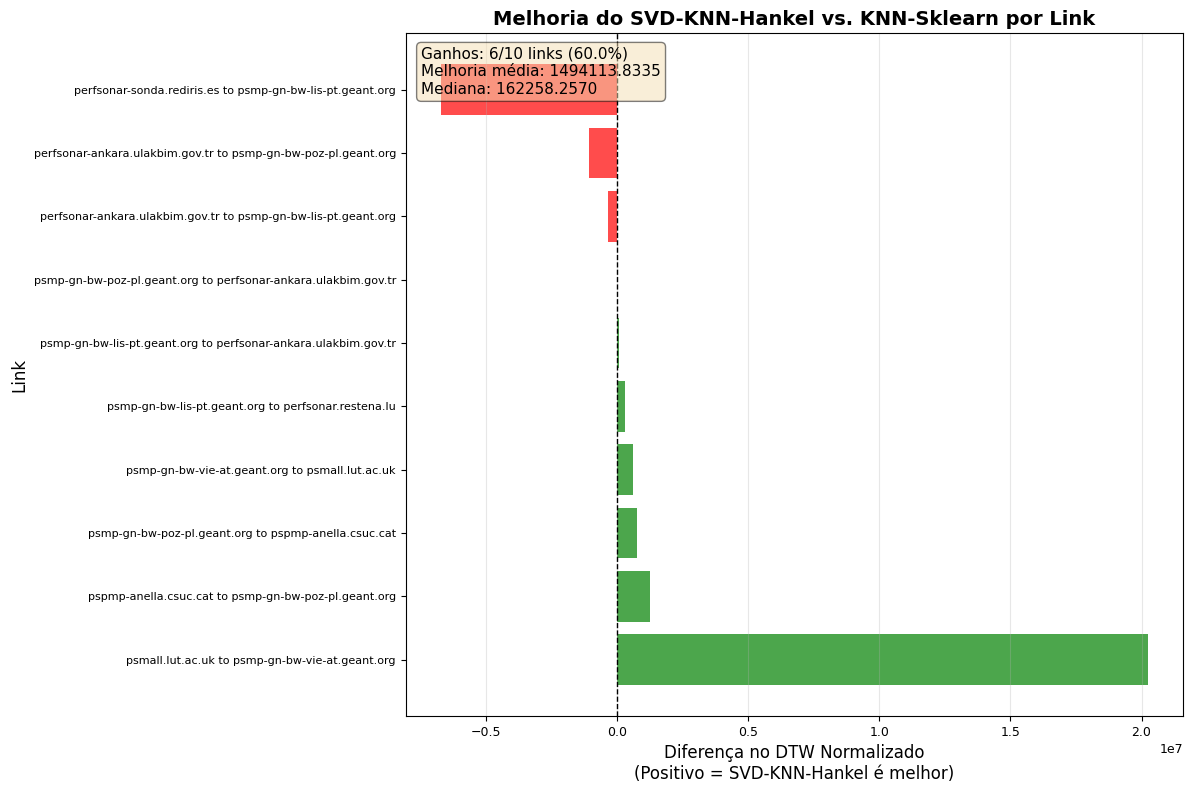

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular diferença (positivo = seu método é melhor)
diferenca = heatmap_data['KNN_Sklearn_imputed'] - heatmap_data['SVD_KNN_Hankel_imputed']

# Ordenar por diferença
diferenca_sorted = diferenca.sort_values(ascending=False)

plt.figure(figsize=(12, 8))
colors = ['green' if x > 0 else 'red' for x in diferenca_sorted.values]
plt.barh(range(len(diferenca_sorted)), diferenca_sorted.values, color=colors, alpha=0.7)
plt.yticks(range(len(diferenca_sorted)), diferenca_sorted.index, fontsize=8)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Diferença no DTW Normalizado\n(Positivo = SVD-KNN-Hankel é melhor)', fontsize=12)
plt.ylabel('Link', fontsize=12)
plt.title('Melhoria do SVD-KNN-Hankel vs. KNN-Sklearn por Link', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Adicionar texto com estatísticas
media_melhoria = diferenca.mean()
wins = (diferenca > 0).sum()
total = len(diferenca)
plt.text(0.02, 0.98, 
         f'Ganhos: {wins}/{total} links ({wins/total*100:.1f}%)\n'
         f'Melhoria média: {media_melhoria:.4f}\n'
         f'Mediana: {diferenca.median():.4f}',
         transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         verticalalignment='top',
         fontsize=11)

plt.tight_layout()
plt.show()

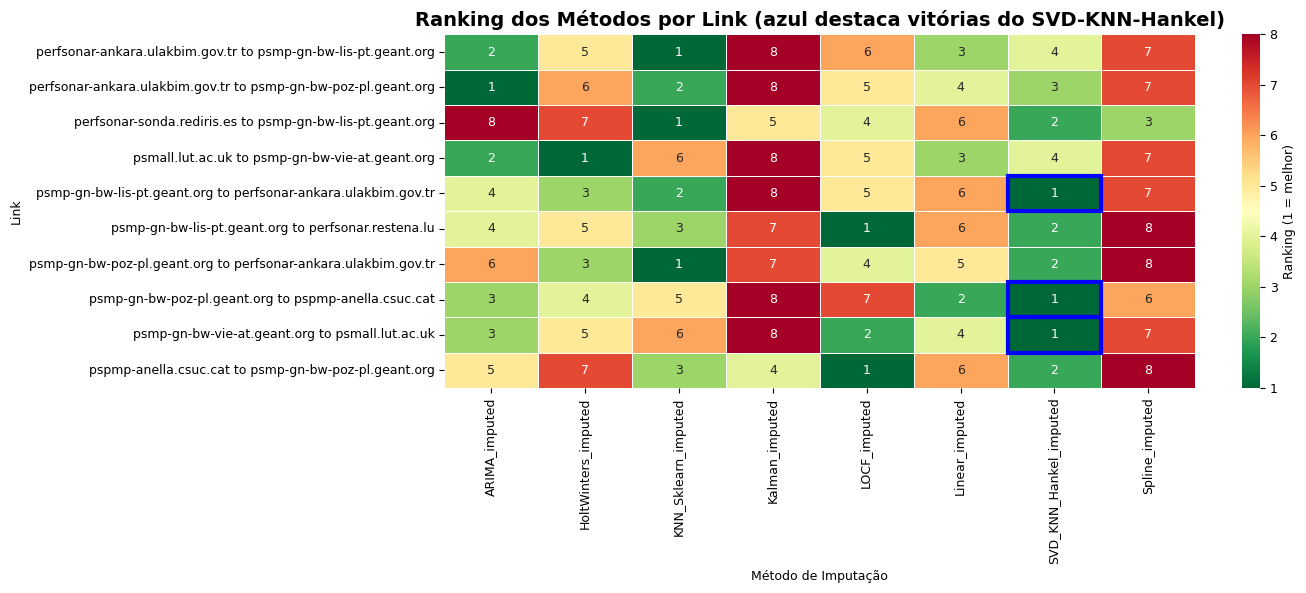


=== RESUMO DE RANKING ===
ARIMA_imputed                 :  1 vitórias | Rank médio: 3.80
HoltWinters_imputed           :  1 vitórias | Rank médio: 4.60
KNN_Sklearn_imputed           :  3 vitórias | Rank médio: 3.00
Kalman_imputed                :  0 vitórias | Rank médio: 7.10
LOCF_imputed                  :  2 vitórias | Rank médio: 4.00
Linear_imputed                :  0 vitórias | Rank médio: 4.50
SVD_KNN_Hankel_imputed        :  3 vitórias | Rank médio: 2.20
Spline_imputed                :  0 vitórias | Rank médio: 6.80


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calcular ranking por linha (1 = melhor)
ranking = heatmap_data.rank(axis=1, method='min')

# Criar heatmap de ranking
fig, ax = plt.subplots(figsize=(14, max(6, len(ranking) * 0.25)))

# Colormap invertido (azul escuro = rank 1)
sns.heatmap(ranking, annot=True, fmt='.0f', cmap='RdYlGn_r', 
            vmin=1, vmax=ranking.max().max(),
            cbar_kws={'label': 'Ranking (1 = melhor)'}, 
            linewidths=0.5, ax=ax)

# Destacar células onde SVD-KNN-Hankel tem rank 1
for i in range(len(ranking)):
    for j, col in enumerate(ranking.columns):
        if col == 'SVD_KNN_Hankel_imputed' and ranking.iloc[i, j] == 1:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, 
                                      edgecolor='blue', linewidth=3))

plt.title('Ranking dos Métodos por Link (azul destaca vitórias do SVD-KNN-Hankel)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Método de Imputação')
plt.ylabel('Link')
plt.tight_layout()
plt.show()

# Estatísticas de ranking
print(f"\n=== RESUMO DE RANKING ===")
for col in ranking.columns:
    rank_1 = (ranking[col] == 1).sum()
    rank_medio = ranking[col].mean()
    print(f"{col:30s}: {rank_1:2d} vitórias | Rank médio: {rank_medio:.2f}")

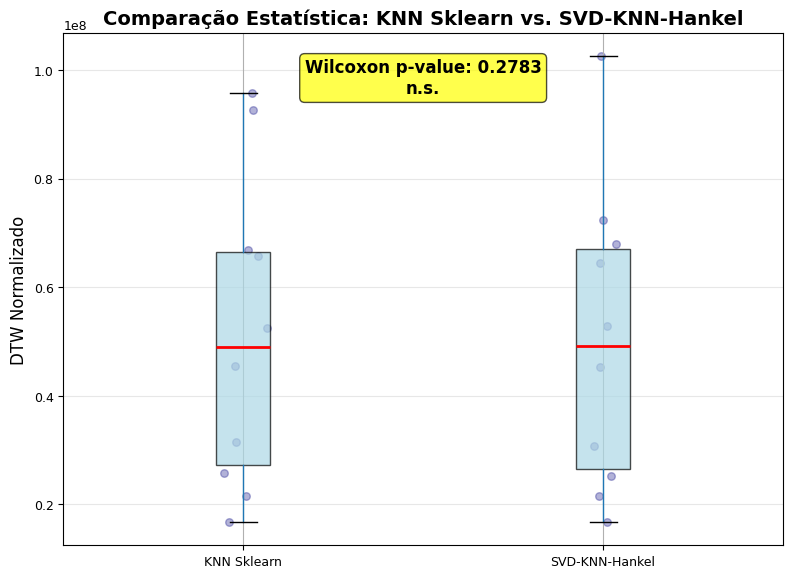

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

# Preparar dados para boxplot
comparacao = heatmap_data[['KNN_Sklearn_imputed', 'SVD_KNN_Hankel_imputed']].copy()
comparacao.columns = ['KNN Sklearn', 'SVD-KNN-Hankel']

fig, ax = plt.subplots(figsize=(8, 6))
bp = comparacao.boxplot(ax=ax, patch_artist=True, 
                         boxprops=dict(facecolor='lightblue', alpha=0.7),
                         medianprops=dict(color='red', linewidth=2))

# Adicionar pontos individuais com transparência
for i, col in enumerate(comparacao.columns):
    y = comparacao[col].values
    x = np.random.normal(i+1, 0.04, size=len(y))
    ax.scatter(x, y, alpha=0.3, s=30, color='navy')

# Teste estatístico
stat, p_value = wilcoxon(comparacao['KNN Sklearn'], 
                         comparacao['SVD-KNN-Hankel'], 
                         alternative='greater')

# Adicionar significância estatística
ax.text(0.5, 0.95, 
        f'Wilcoxon p-value: {p_value:.4f}\n'
        f'{"***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "n.s."}',
        transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
        verticalalignment='top',
        horizontalalignment='center',
        fontsize=12,
        fontweight='bold')

ax.set_ylabel('DTW Normalizado', fontsize=12)
ax.set_title('Comparação Estatística: KNN Sklearn vs. SVD-KNN-Hankel', 
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### FAM

In [130]:
# ==============================
# CONFIG
# ==============================
import os, re, warnings
import numpy as np
import pandas as pd
from pathlib import Path

PREDICTIONS_FOLDER = Path("predictions_gru")       # onde estão os arquivos _gru.csv
ORIGINALS_FOLDER   = Path("../aggregated_6h_datasets")  # originais 6h
VALUE_COLS         = ("Vazao", "throughput_bps", "value", "n_bytes", "bytes")

# Bins em Mbps
BINS_MBPS = np.arange(0, 2100, 100)
LABELS = [f"{BINS_MBPS[i]}-{BINS_MBPS[i+1]}" for i in range(len(BINS_MBPS)-1)]

# ==============================
# FUZZY ACCURACY HELPERS
# ==============================
def fuzzy_weight(distance: int) -> float:
    """Atribui pesos suavizados conforme a distância entre bins."""
    return {0: 1.0, 1: 0.75, 2: 0.5}.get(distance, 0.0)

def compute_fuzzy_accuracy(y_true, y_pred):
    """Calcula a fuzzy accuracy média (0–1) com robustez de tipo."""
    df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred}).dropna()
    if df.empty:
        return None, 0

    # Converte para Mbps
    df['y_true_mbps'] = df['y_true'] / 1e6
    df['y_pred_mbps'] = df['y_pred'] / 1e6

    # Atribui bins
    df['true_bin'] = pd.cut(df['y_true_mbps'], bins=BINS_MBPS, labels=LABELS, right=False)
    df['pred_bin'] = pd.cut(df['y_pred_mbps'], bins=BINS_MBPS, labels=LABELS, right=False)

    # Mapeia para índices inteiros
    label_to_index = {label: idx for idx, label in enumerate(LABELS)}
    df['true_idx'] = df['true_bin'].map(label_to_index)
    df['pred_idx'] = df['pred_bin'].map(label_to_index)

    # Garante que são inteiros
    df = df.dropna(subset=['true_idx', 'pred_idx'])
    if df.empty:
        return None, 0

    df['true_idx'] = df['true_idx'].astype(int)
    df['pred_idx'] = df['pred_idx'].astype(int)

    # Calcula distância de bins
    df['distance'] = (df['true_idx'] - df['pred_idx']).abs()
    df['fuzzy_weight'] = df['distance'].apply(fuzzy_weight)

    return df['fuzzy_weight'].mean(), len(df)


# ==============================
# I/O HELPERS
# ==============================
def _read_series(csv_path: Path, value_cols=VALUE_COLS):
    """Lê série de valores numéricos a partir do CSV."""
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        warnings.warn(f"Falha lendo {csv_path}: {e}")
        return None
    col = next((c for c in value_cols if c in df.columns), None)
    if col is None:
        num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        if not num_cols:
            warnings.warn(f"Nenhuma coluna numérica em {csv_path.name}")
            return None
        col = num_cols[0]
    s = pd.to_numeric(df[col], errors='coerce').dropna()
    return s.reset_index(drop=True)

def _safe_align(y1: pd.Series, y2: pd.Series):
    """Alinha duas séries pelo comprimento mínimo e remove NaNs."""
    n = int(min(len(y1), len(y2)))
    y1 = y1.iloc[:n].astype(float)
    y2 = y2.iloc[:n].astype(float)
    mask = ~(y1.isna() | y2.isna())
    return y1[mask].to_numpy(), y2[mask].to_numpy(), int(mask.sum())

def find_original_series(pred_file: Path, originals_folder=ORIGINALS_FOLDER):
    """Tenta localizar CSV original correspondente com base no prefixo do nome."""
    base = pred_file.name.split("_6h_")[0].lower()
    for csv in originals_folder.rglob("*.csv"):
        if base in csv.name.lower():
            s = _read_series(csv)
            if s is not None and len(s) > 0:
                return s, csv
    return None, None

# ==============================
# FAM EVALUATION
# ==============================
def evaluate_fuzzy_accuracy_predictions(predictions_folder=PREDICTIONS_FOLDER):
    """Calcula FAM (Fuzzy Accuracy Metric) para todos os arquivos _gru.csv."""
    results = []

    pred_files = sorted(predictions_folder.glob("*_6h_*_gru.csv"))
    if not pred_files:
        print("Nenhum arquivo encontrado em predictions_gru.")
        return pd.DataFrame()

    for pred_path in pred_files:
        # Extrai método
        method_match = re.search(r"_6h_(.+?)\.csv_gru\.csv$", pred_path.name)
        method = method_match.group(1) if method_match else "Unknown"

        # Lê séries
        y_pred = _read_series(pred_path)
        y_true, orig_path = find_original_series(pred_path, ORIGINALS_FOLDER)
        if y_pred is None or y_true is None:
            print(f"[skip] sem dados válidos para {pred_path.name}")
            continue

        y_true_a, y_pred_a, n = _safe_align(y_true, y_pred)
        if n < 10:
            continue

        acc, count = compute_fuzzy_accuracy(y_true_a, y_pred_a)
        if acc is None:
            continue

        results.append({
            "File": pred_path.name,
            "ImputationMethod": method,
            "Fuzzy_Accuracy": acc * 100.0,
            "Samples": count,
            "OriginalFile": str(orig_path) if orig_path else None
        })

    return pd.DataFrame(results)

# ==============================
# EXECUÇÃO E AGREGAÇÃO
# ==============================
pd.options.display.float_format = "{:.2f}".format

df_fam = evaluate_fuzzy_accuracy_predictions()

if not df_fam.empty:
    # Estatísticas resumidas
    fam_summary = (
        df_fam.groupby("ImputationMethod")["Fuzzy_Accuracy"]
        .agg(["count", "mean", "std", "min", "max"])
        .sort_values("mean", ascending=False)
        .round(2)
    )

    df_fam.to_csv("fuzzy_accuracy_prediction_gru.csv", index=False)
    fam_summary.to_csv("fuzzy_accuracy_summary_prediction_gru.csv")

    print("Resumo Fuzzy Accuracy por método:")
    display(fam_summary)

    print("\nResultados detalhados salvos em fuzzy_accuracy_prediction_gru.csv")
else:
    print("Nenhum resultado FAM calculado.")


Resumo Fuzzy Accuracy por método:


,count,mean,std,min,max
ImputationMethod,,,,,
KNN_Sklearn_imputed,9,86.39,10.57,59.72,95.49
Mean_imputed,9,86.39,10.57,59.72,95.49
SVD_KNN_Hankel_imputed,9,86.39,10.57,59.72,95.49
SVD_KNN_imputed,9,86.35,10.70,59.33,95.49
LOCF_imputed,10,82.19,10.68,59.72,95.49
ARIMA_imputed,10,72.35,27.73,10.00,95.49
HoltWinters_imputed,10,72.28,28.19,11.63,95.49
IterativeSVD_imputed,10,71.05,29.55,11.63,95.49
Linear_imputed,10,71.05,29.55,11.63,95.49



Resultados detalhados salvos em fuzzy_accuracy_prediction_gru.csv


### Ajustando resultados das predições para ficar mais fácil 

In [ ]:
# import json

# def listar_chaves_json(caminho_arquivo):
#     """Lê um JSON e imprime todas as chaves únicas do nível superior."""
#     with open(caminho_arquivo, 'r', encoding='utf-8') as f:
#         data = json.load(f)

#     print("Chaves únicas encontradas:")
#     for chave in data.keys():
#         print(chave)

# # Exemplo de uso:
# listar_chaves_json("../evaluation_rmse_mae.json")


Chaves únicas encontradas:
esmond data perfsonar-ankara.ulakbim.gov.tr to psmp-gn-bw-lis-pt.geant.org 10-24-2023_6h_Mean_imputed.csv
esmond data perfsonar-sonda.rediris.es to psmp-gn-bw-lis-pt.geant.org 10-24-2023_6h_ARIMA_imputed.csv
esmond data perfsonar-ankara.ulakbim.gov.tr to psmp-gn-bw-lis-pt.geant.org 10-24-2023_6h_IterativeSVD_imputed.csv
esmond data psmp-gn-bw-lis-pt.geant.org to perfsonar-ankara.ulakbim.gov.tr 10-24-2023_6h_SVD_KNN_imputed.csv
esmond data psmp-gn-bw-poz-pl.geant.org to pspmp-anella.csuc.cat 10-24-2023_6h_Spline_imputed.csv
esmond data pspmp-anella.csuc.cat to psmp-gn-bw-poz-pl.geant.org 10-24-2023_6h_Spline_imputed.csv
esmond data psmp-gn-bw-vie-at.geant.org to psmall.lut.ac.uk 10-24-2023_6h_LOCF_imputed.csv
esmond data psmp-gn-bw-lis-pt.geant.org to perfsonar-ankara.ulakbim.gov.tr 10-24-2023_6h_HoltWinters_imputed.csv
esmond data psmp-gn-bw-poz-pl.geant.org to pspmp-anella.csuc.cat 10-24-2023_6h_IterativeSVD_imputed.csv
esmond data psmp-gn-bw-lis-pt.geant.or

In [ ]:
# import os
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from pathlib import Path
# from scipy.spatial.distance import euclidean
# from fastdtw import fastdtw
# import warnings

# warnings.filterwarnings("ignore")

# # =====================================================
# # CONFIGURAÇÃO
# # =====================================================
# PREDICTIONS_FOLDER = Path("predictions_gru")  # Pasta com arquivos CSV (original, prediction)
# OUTPUT_CSV = "gru_dtw_metrics_summary.csv"
# FIGURES_FOLDER = Path("gru_dtw_figures")
# FIGURES_FOLDER.mkdir(exist_ok=True)

# # =====================================================
# # FUNÇÕES DE MÉTRICAS
# # =====================================================
# def rmse(y_true, y_pred):
#     mask = ~(np.isnan(y_true) | np.isnan(y_pred))
#     if not np.any(mask): return np.nan
#     return np.sqrt(np.mean((y_true[mask] - y_pred[mask])**2))

# def mae(y_true, y_pred):
#     mask = ~(np.isnan(y_true) | np.isnan(y_pred))
#     if not np.any(mask): return np.nan
#     return np.mean(np.abs(y_true[mask] - y_pred[mask]))

# def nrmse(y_true, y_pred, mode="range"):
#     mask = ~(np.isnan(y_true) | np.isnan(y_pred))
#     if not np.any(mask): return np.nan
#     denom = (np.max(y_true[mask]) - np.min(y_true[mask])) if mode == "range" else np.std(y_true[mask])
#     return rmse(y_true, y_pred) / denom if denom != 0 else np.nan

# def mape(y_true, y_pred):
#     mask = ~(np.isnan(y_true) | np.isnan(y_pred) | (y_true == 0))
#     if not np.any(mask): return np.nan
#     return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# def r2_score(y_true, y_pred):
#     mask = ~(np.isnan(y_true) | np.isnan(y_pred))
#     if not np.any(mask): return np.nan
#     ss_res = np.sum((y_true[mask] - y_pred[mask])**2)
#     ss_tot = np.sum((y_true[mask] - np.mean(y_true[mask]))**2)
#     return 1 - ss_res/ss_tot if ss_tot != 0 else np.nan

# def dtw_distance(y_true, y_pred):
#     mask = ~(np.isnan(y_true) | np.isnan(y_pred))
#     if not np.any(mask): return np.nan, np.nan
#     try:
#         dist, _ = fastdtw(y_true[mask].reshape(-1, 1), y_pred[mask].reshape(-1, 1), dist=euclidean)
#         norm = dist / len(y_true[mask])
#         return dist, norm
#     except Exception as e:
#         warnings.warn(f"DTW failed: {e}")
#         return np.nan, np.nan

# # =====================================================
# # AVALIAÇÃO E SALVAMENTO
# # =====================================================
# def evaluate_predictions(folder=PREDICTIONS_FOLDER, output_file=OUTPU_


Encontrados 120 arquivos para análise em 'predictions_gru'
[OK] esmond data perfsonar-ankara.ulakbim.gov.tr to psmp-gn-bw-lis-pt.geant.org 10-24-2023_6h_ARIMA_imputed.csv_gru.csv  RMSE=84223710.53  DTW=7538977213.54
[OK] esmond data perfsonar-ankara.ulakbim.gov.tr to psmp-gn-bw-lis-pt.geant.org 10-24-2023_6h_HoltWinters_imputed.csv_gru.csv  RMSE=85078383.01  DTW=7606731272.97
[OK] esmond data perfsonar-ankara.ulakbim.gov.tr to psmp-gn-bw-lis-pt.geant.org 10-24-2023_6h_IterativeSVD_imputed.csv_gru.csv  RMSE=82755938.81  DTW=7553696757.49
[OK] esmond data perfsonar-ankara.ulakbim.gov.tr to psmp-gn-bw-lis-pt.geant.org 10-24-2023_6h_Kalman_imputed.csv_gru.csv  RMSE=442964910.20  DTW=62237394144.21
[OK] esmond data perfsonar-ankara.ulakbim.gov.tr to psmp-gn-bw-lis-pt.geant.org 10-24-2023_6h_KNN_Sklearn_imputed.csv_gru.csv  RMSE=83563089.21  DTW=7511683512.00
[OK] esmond data perfsonar-ankara.ulakbim.gov.tr to psmp-gn-bw-lis-pt.geant.org 10-24-2023_6h_Linear_imputed.csv_gru.csv  RMSE=8275593

C:\Users\Clara\AppData\Local\Temp\ipykernel_2352\3577752694.py:166: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="rmse", y="file", data=top10, palette="crest")


Plots salvos em: C:\Users\Clara\Documents\Pesquisa\enhanced-svd\jisa_experiments\gru_metrics_figures


In [ ]:
# import json
# import re

# def listar_chaves_unicas_sem_sufixo(caminho_arquivo):
#     """
#     Lê um JSON e imprime as chaves únicas removendo o que vem após o primeiro underline.
#     Exemplo:
#         "dataset_6h_Mean_imputed.csv" → "dataset"
#     """
#     with open(caminho_arquivo, 'r', encoding='utf-8') as f:
#         data = json.load(f)

#     chaves_originais = list(data.keys())
#     chaves_limpa = []

#     for chave in chaves_originais:
#         # Divide no primeiro underline
#         base = chave.split('_', 1)[0]
#         chaves_limpa.append(base.strip())

#     # Remove duplicadas preservando a ordem
#     unicas = list(dict.fromkeys(chaves_limpa))

#     print("Chaves únicas (sem sufixo após o primeiro underscore):")
#     for c in unicas:
#         print(c)

#     return unicas

# # Exemplo de uso:
# listar_chaves_unicas_sem_sufixo("../evaluation_rmse_mae_arima.json")


Chaves únicas (sem sufixo após o primeiro underscore):
esmond data perfsonar-ankara.ulakbim.gov.tr to psmp-gn-bw-lis-pt.geant.org 10-24-2023
esmond data perfsonar-sonda.rediris.es to psmp-gn-bw-lis-pt.geant.org 10-24-2023
esmond data psmp-gn-bw-lis-pt.geant.org to perfsonar-ankara.ulakbim.gov.tr 10-24-2023
esmond data psmp-gn-bw-poz-pl.geant.org to pspmp-anella.csuc.cat 10-24-2023
esmond data pspmp-anella.csuc.cat to psmp-gn-bw-poz-pl.geant.org 10-24-2023
esmond data psmp-gn-bw-vie-at.geant.org to psmall.lut.ac.uk 10-24-2023
esmond data psmp-gn-bw-poz-pl.geant.org to perfsonar-ankara.ulakbim.gov.tr 10-24-2023
esmond data psmall.lut.ac.uk to psmp-gn-bw-vie-at.geant.org 10-24-2023
esmond data psmp-gn-bw-lis-pt.geant.org to perfsonar.restena.lu 10-24-2023
imputation
esmond data perfsonar-ankara.ulakbim.gov.tr to psmp-gn-bw-poz-pl.geant.org 10-24-2023


['esmond data perfsonar-ankara.ulakbim.gov.tr to psmp-gn-bw-lis-pt.geant.org 10-24-2023',
 'esmond data perfsonar-sonda.rediris.es to psmp-gn-bw-lis-pt.geant.org 10-24-2023',
 'esmond data psmp-gn-bw-lis-pt.geant.org to perfsonar-ankara.ulakbim.gov.tr 10-24-2023',
 'esmond data psmp-gn-bw-poz-pl.geant.org to pspmp-anella.csuc.cat 10-24-2023',
 'esmond data pspmp-anella.csuc.cat to psmp-gn-bw-poz-pl.geant.org 10-24-2023',
 'esmond data psmp-gn-bw-vie-at.geant.org to psmall.lut.ac.uk 10-24-2023',
 'esmond data psmp-gn-bw-poz-pl.geant.org to perfsonar-ankara.ulakbim.gov.tr 10-24-2023',
 'esmond data psmall.lut.ac.uk to psmp-gn-bw-vie-at.geant.org 10-24-2023',
 'esmond data psmp-gn-bw-lis-pt.geant.org to perfsonar.restena.lu 10-24-2023',
 'imputation',
 'esmond data perfsonar-ankara.ulakbim.gov.tr to psmp-gn-bw-poz-pl.geant.org 10-24-2023']